# Tying the (Data) Knot: Love, Life & Likes
## WIA1006/WID3006 Machine Learning - Group Assignment

**Objective:** Predict relationship match outcomes from a synthetic dating app dataset (50,000 records) using multiple ML models.

**Group 8 Members:**
- Raye Chan Jun Foong (Leader) - Pipeline Architecture & XGBoost
- Yip Zheng Xyun - Data Preprocessing & Feature Engineering
- Hon Chi Fung - Logistic Regression & Feature Selection
- Ong Zheng Xi - Random Forest & Hyperparameter Tuning
- Daniel Goh Zhi Qian - Decision Tree & Error Analysis
- Lau Wei Zhong - SVM & Ensembling

---
## Table of Contents
1. [Task 1: Data Preprocessing](#task1)
2. [Task 2: Feature Engineering & Selection](#task2)
3. [Task 3: Model Selection & Training](#task3)
4. [Task 4: Model Evaluation & Comparison](#task4)
5. [Task 5: Hyperparameter Tuning](#task5)
6. [Bonus: Balancing Techniques (SMOTE)](#bonus)
7. [Conclusion](#conclusion)

---
## Setup: Install & Import Dependencies

In [1]:
# Install required packages (uncomment if needed)
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap imbalanced-learn joblib

import warnings
warnings.filterwarnings("ignore")

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV, learning_curve, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTEENN

# Visualization settings
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.dpi'] = 150
PALETTE = "viridis"

# Paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_PATH = os.path.join(BASE_DIR, "data", "dating_app_behavior_dataset.csv")
MODELS_DIR = os.path.join(BASE_DIR, "models")
VIZ_DIR = os.path.join(BASE_DIR, "visualizations")
REPORTS_DIR = os.path.join(BASE_DIR, "reports")

for d in [MODELS_DIR, VIZ_DIR, REPORTS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Setup complete.")

Setup complete.


---
## 1. Task 1: Data Preprocessing <a id='task1'></a>

### 1.1 Load the Dataset

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\nColumn types:")
print(df.dtypes)
df.head()

Dataset shape: 50000 rows x 19 columns

Column types:
gender                      str
sexual_orientation          str
location_type               str
income_bracket              str
education_level             str
interest_tags               str
app_usage_time_min        int64
app_usage_time_label        str
swipe_right_ratio       float64
swipe_right_label           str
likes_received            int64
mutual_matches            int64
profile_pics_count        int64
bio_length                int64
message_sent_count        int64
emoji_usage_rate        float64
last_active_hour          int64
swipe_time_of_day           str
match_outcome               str
dtype: object


,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,app_usage_time_label,swipe_right_ratio,swipe_right_label,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome
0,Prefer Not to Say,Gay,Urban,High,Bachelor’s,"Fitness, Politics, Traveling",52,Moderate,0.60,Optimistic,173,23,4,44,75,0.36,13,Early Morning,Mutual Match
1,Male,Bisexual,Suburban,Upper-Middle,No Formal Education,"Languages, Fashion, Parenting",279,Extreme User,0.56,Optimistic,107,7,3,301,35,0.42,0,Morning,Chat Ignored
2,Non-binary,Pansexual,Suburban,Low,Master’s,"Movies, Reading, DIY",49,Moderate,0.41,Optimistic,91,27,2,309,33,0.41,1,After Midnight,Date Happened
3,Genderfluid,Gay,Metro,Very Low,Postdoc,"Coding, Podcasts, History",185,Extreme User,0.32,Balanced,147,6,5,35,5,0.07,21,Morning,No Action
4,Male,Bisexual,Urban,Middle,Bachelor’s,"Clubbing, Podcasts, Cars",83,High,0.32,Balanced,94,11,1,343,34,0.11,22,After Midnight,One-sided Like


### 1.2 Summary Statistics

In [3]:
# Summary statistics for numerical features
df.describe()

,app_usage_time_min,swipe_right_ratio,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.00000,50000.000000,50000.000000
mean,149.912400,0.500655,99.526040,13.870280,2.98772,250.174400,50.07194,0.286205,11.521800
std,86.990521,0.197468,57.996799,9.105615,1.99678,144.800996,29.16800,0.160042,6.920474
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000
25%,74.000000,0.370000,49.000000,6.000000,1.00000,125.000000,25.00000,0.160000,5.000000
50%,150.000000,0.500000,100.000000,13.000000,3.00000,250.000000,50.00000,0.270000,12.000000
75%,225.000000,0.640000,150.000000,22.000000,5.00000,376.000000,75.00000,0.390000,18.000000
max,300.000000,1.000000,200.000000,30.000000,6.00000,500.000000,100.00000,0.940000,23.000000


In [4]:
# Summary statistics for categorical features
df.describe(include=['object'])

,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_label,swipe_right_label,swipe_time_of_day,match_outcome
count,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000
unique,6,8,6,7,9,40206,7,4,6,10
top,Female,Straight,Remote Area,High,Bachelor’s,"Fitness, Anime, Yoga",Extreme User,Optimistic,After Midnight,One-sided Like
freq,8384,6326,8519,7309,5646,6,20140,26873,8524,5112


### 1.3 Data Cleaning

**Dropped columns (justification):**
- `mutual_matches`: Target leakage - directly encodes match information
- `app_usage_time_label`: Derived bin of `app_usage_time_min` (redundant)
- `swipe_right_label`: Derived bin of `swipe_right_ratio` (redundant)
- `sexual_orientation`: Not in recommended feature list

In [5]:
DROP_COLS = [
    "mutual_matches",       # Target leakage
    "app_usage_time_label", # Redundant (derived bin)
    "swipe_right_label",    # Redundant (derived bin)
    "sexual_orientation",   # Not recommended
]

existing_drops = [c for c in DROP_COLS if c in df.columns]
df = df.drop(columns=existing_drops)
print(f"Dropped columns: {existing_drops}")
print(f"Shape after dropping: {df.shape}")

Dropped columns: ['mutual_matches', 'app_usage_time_label', 'swipe_right_label', 'sexual_orientation']
Shape after dropping: (50000, 15)


### 1.4 Target Variable: Group 10 Outcomes into 3 Classes

The original `match_outcome` has 10 categories. We group them into 3 meaningful classes:
- **Positive:** Mutual Match, Date Happened, Relationship Formed, Instant Match
- **Neutral:** No Action, One-sided Like, Chat Ignored
- **Negative:** Ghosted, Blocked, Catfished

In [6]:
TARGET = "match_outcome"

TARGET_MAP = {
    "Mutual Match": "Positive", "Date Happened": "Positive",
    "Relationship Formed": "Positive", "Instant Match": "Positive",
    "No Action": "Neutral", "One-sided Like": "Neutral", "Chat Ignored": "Neutral",
    "Ghosted": "Negative", "Blocked": "Negative", "Catfished": "Negative",
}

df[TARGET] = df[TARGET].map(TARGET_MAP)
unmapped = df[TARGET].isna().sum()
if unmapped:
    print(f"WARNING: {unmapped} unmapped rows - dropping")
    df = df.dropna(subset=[TARGET])

print("Target distribution after grouping:")
print(df[TARGET].value_counts())

# Encode target
label_encoder = LabelEncoder()
df[TARGET] = label_encoder.fit_transform(df[TARGET])
CLASS_NAMES = list(label_encoder.classes_)
print(f"\nEncoded classes: {CLASS_NAMES}")

Target distribution after grouping:
match_outcome
Positive    19850
Neutral     15117
Negative    15033
Name: count, dtype: int64

Encoded classes: ['Negative', 'Neutral', 'Positive']


### 1.5 Handle Missing Values & Outliers

In [7]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

Missing values per column:
No missing values found.


In [8]:
# Outlier detection using IQR method
numerical_cols_check = ['app_usage_time_min', 'swipe_right_ratio', 'likes_received',
                        'profile_pics_count', 'bio_length', 'message_sent_count',
                        'emoji_usage_rate', 'last_active_hour']

outlier_summary = {}
for col in numerical_cols_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = outliers

outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Outlier Count'])
print("Outlier counts (IQR method):")
print(outlier_df)

Outlier counts (IQR method):
                    Outlier Count
app_usage_time_min              0
swipe_right_ratio               0
likes_received                  0
profile_pics_count              0
bio_length                      0
message_sent_count              0
emoji_usage_rate              311
last_active_hour                0


### 1.6 Categorical Encoding & Numerical Scaling

We build a `ColumnTransformer` pipeline:
- **Numerical:** SimpleImputer (median) → StandardScaler
- **Categorical:** SimpleImputer (mode) → OneHotEncoder

In [9]:
NUMERICAL_FEATURES = [
    "app_usage_time_min", "swipe_right_ratio", "likes_received",
    "profile_pics_count", "bio_length", "message_sent_count",
    "emoji_usage_rate", "last_active_hour",
]

CATEGORICAL_FEATURES = [
    "gender", "education_level", "income_bracket", "location_type", "swipe_time_of_day",
]

print(f"Numerical features ({len(NUMERICAL_FEATURES)}): {NUMERICAL_FEATURES}")
print(f"Categorical features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")

Numerical features (8): ['app_usage_time_min', 'swipe_right_ratio', 'likes_received', 'profile_pics_count', 'bio_length', 'message_sent_count', 'emoji_usage_rate', 'last_active_hour']
Categorical features (5): ['gender', 'education_level', 'income_bracket', 'location_type', 'swipe_time_of_day']


### 1.7 Exploratory Data Analysis (EDA)

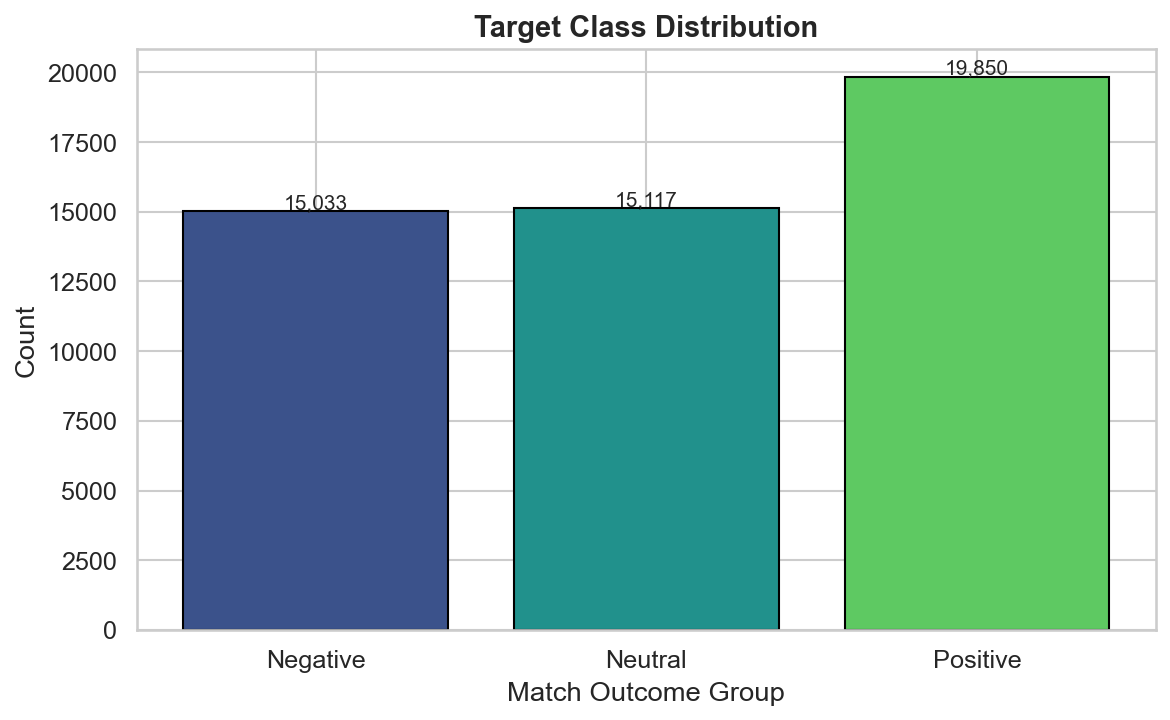

In [10]:
# 1. Class Distribution
fig, ax = plt.subplots(figsize=(8, 5))
counts = df[TARGET].value_counts().sort_index()
labels = [CLASS_NAMES[i] for i in counts.index]
bars = ax.bar(labels, counts.values, color=sns.color_palette(PALETTE, len(counts)), edgecolor="black")
ax.set_title("Target Class Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Match Outcome Group")
ax.set_ylabel("Count")
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 100, f"{v:,}", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "01_class_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

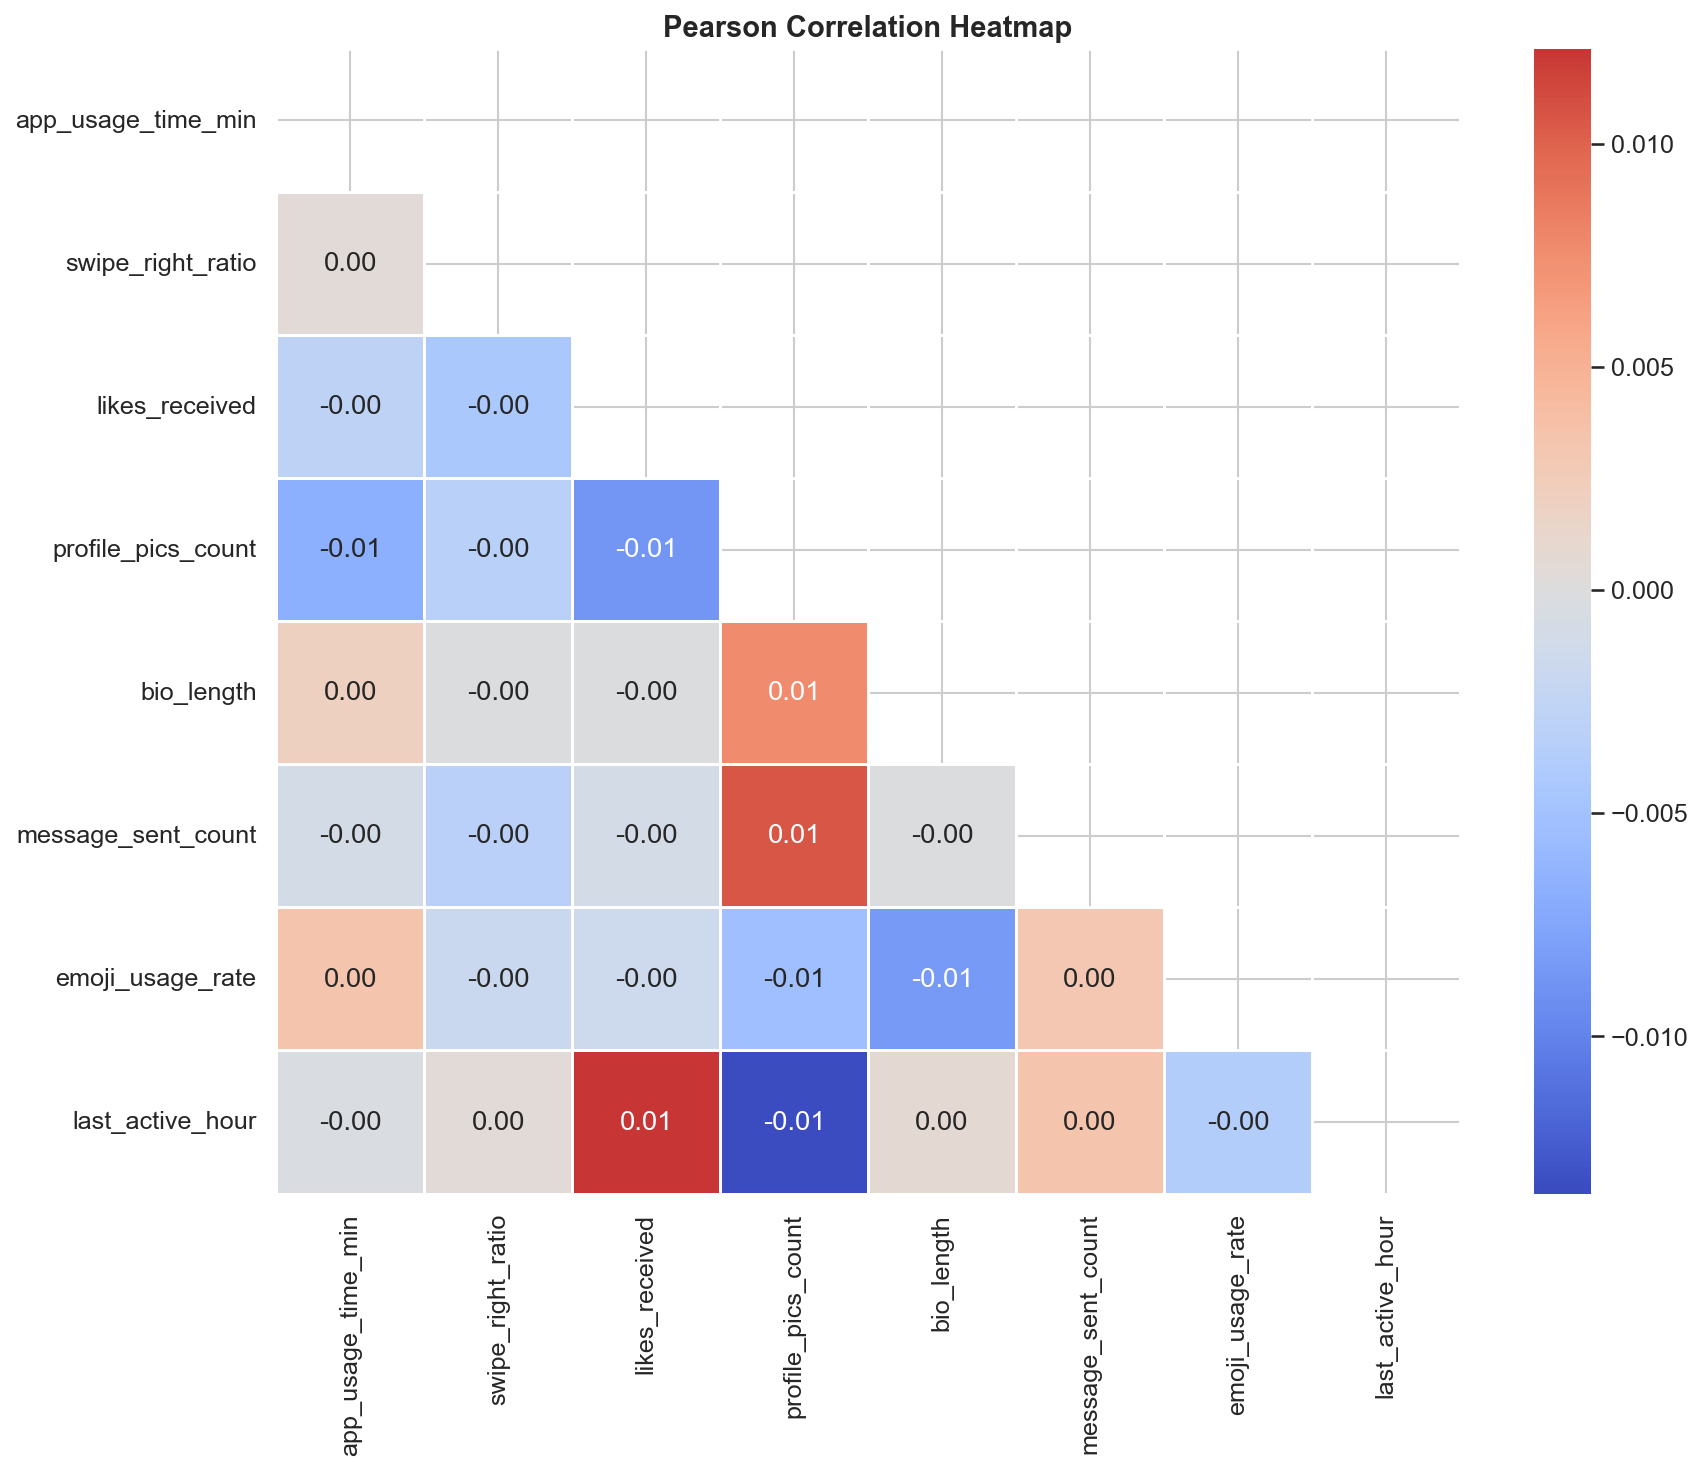

In [11]:
# 2. Correlation Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
corr = df[NUMERICAL_FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Pearson Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "02_correlation_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

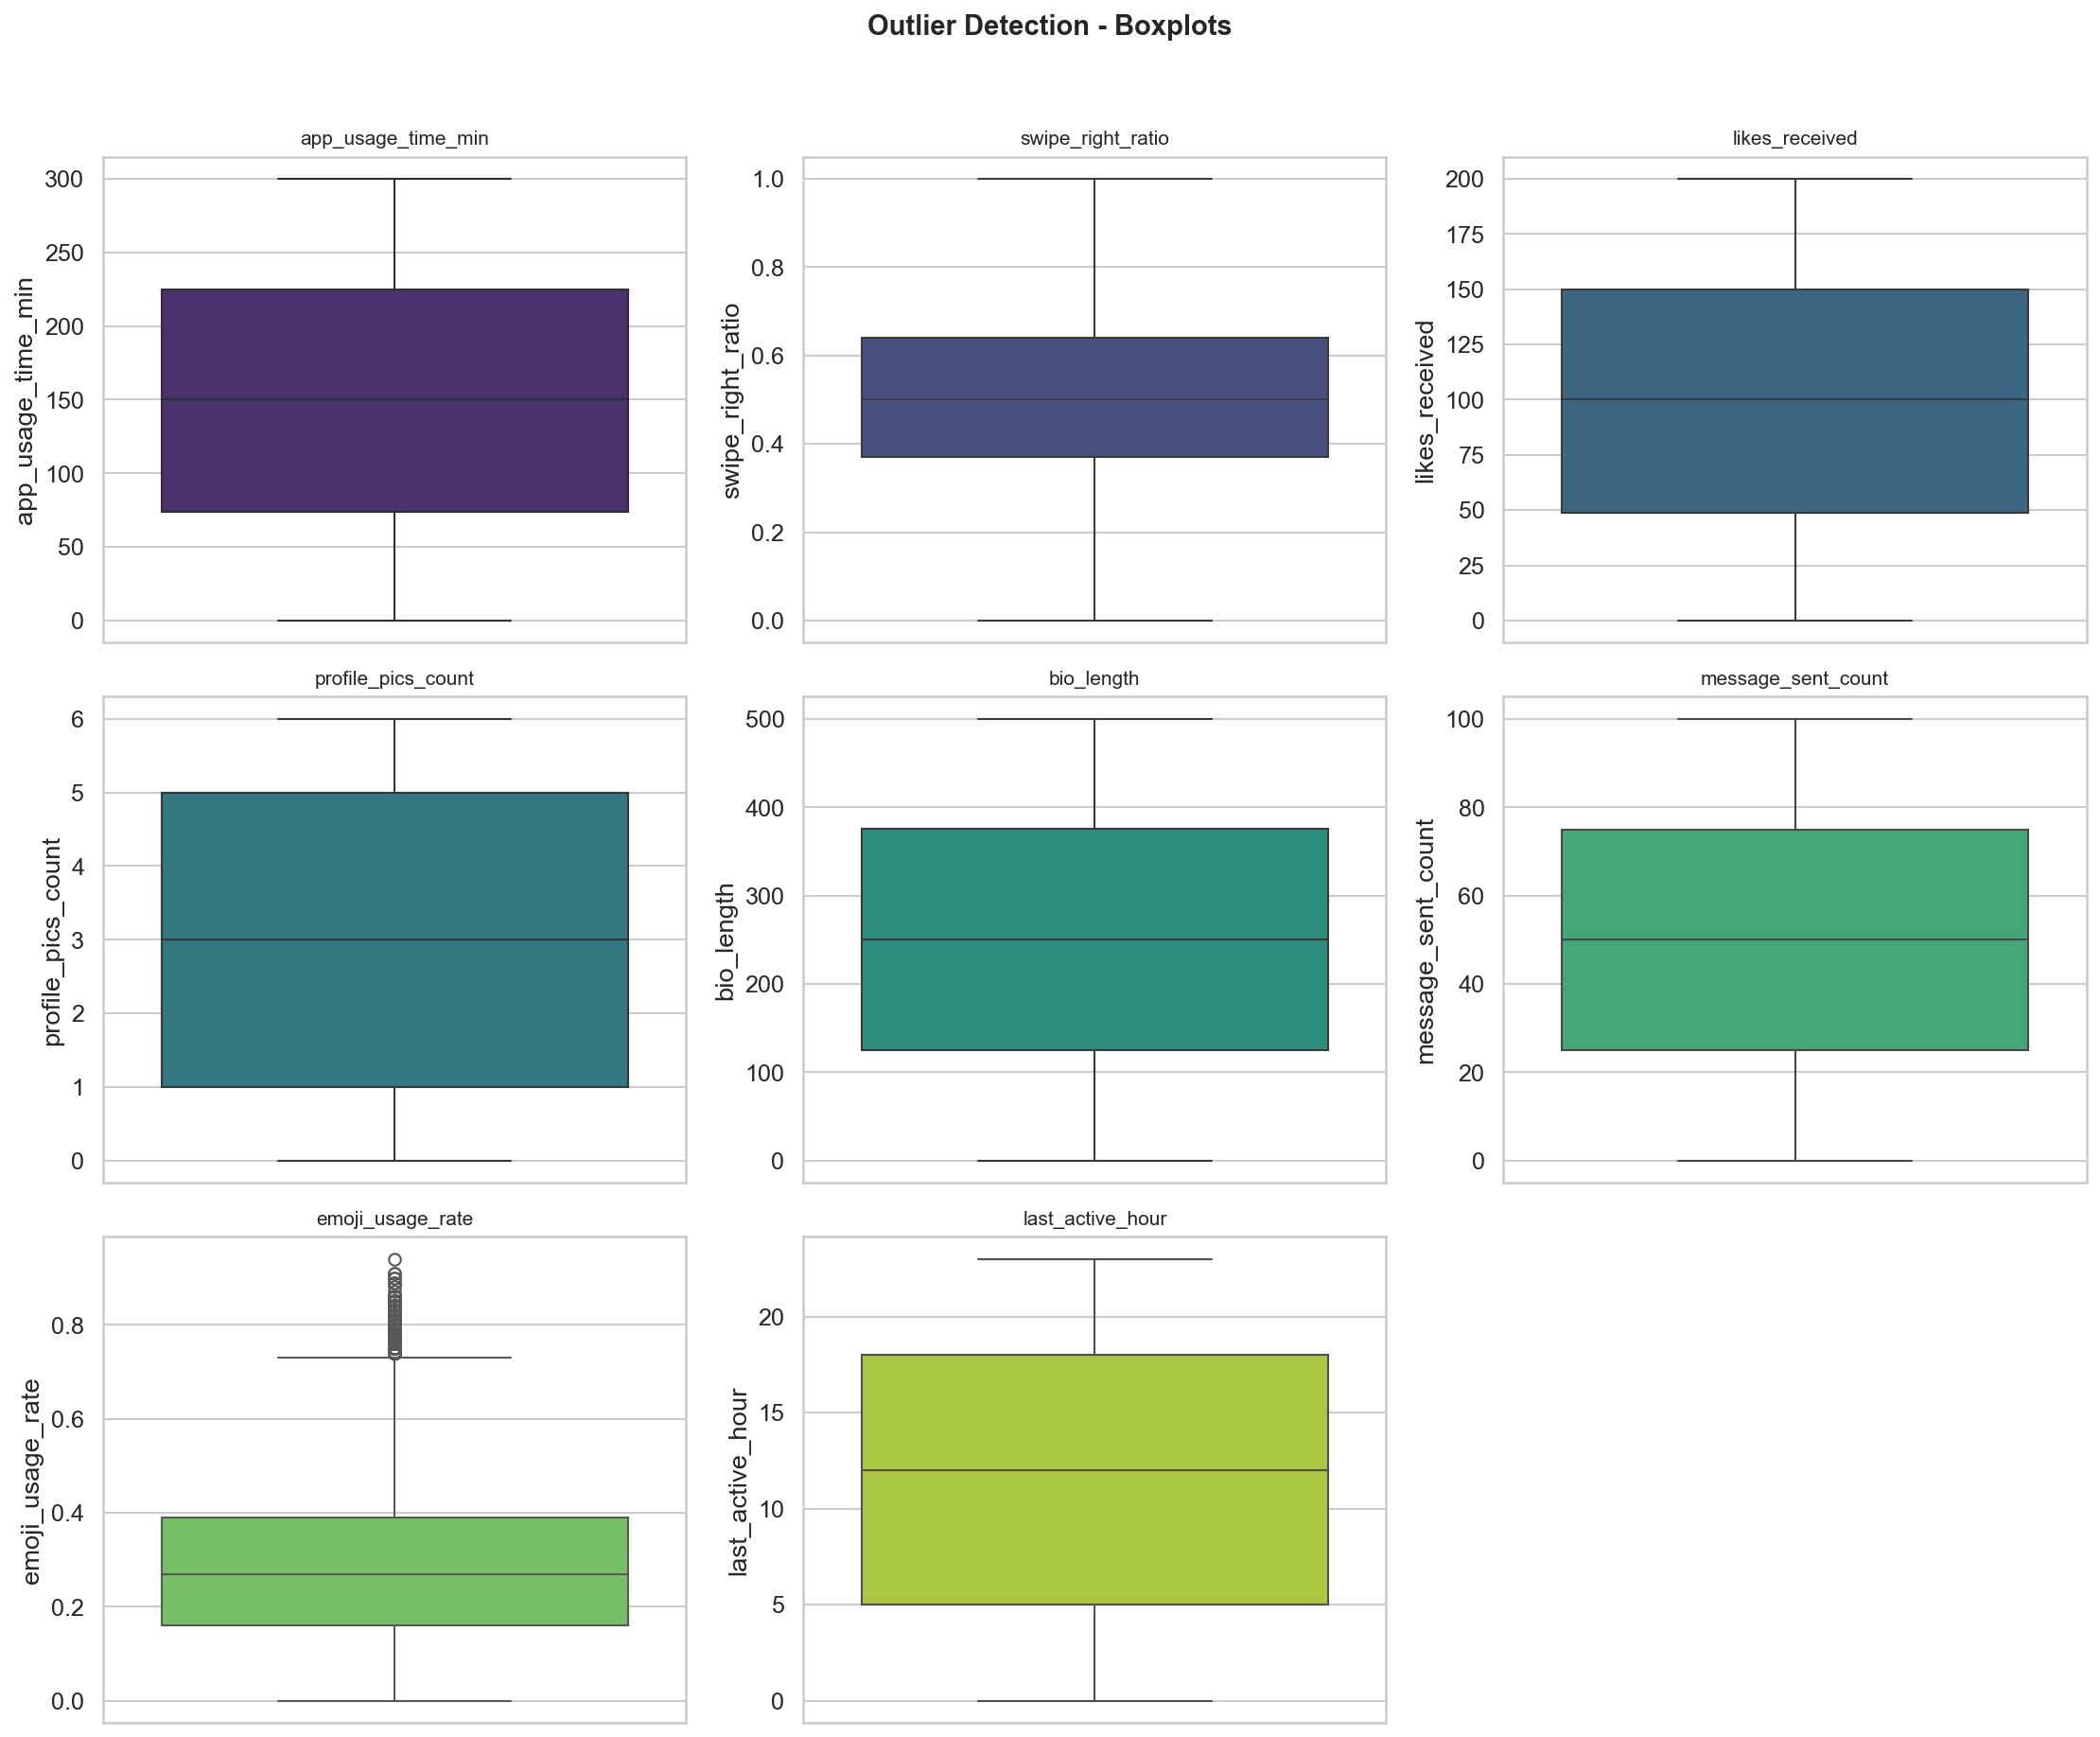

In [12]:
# 3. Boxplots for Outlier Detection
n = len(NUMERICAL_FEATURES)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()
for i, col in enumerate(NUMERICAL_FEATURES):
    sns.boxplot(y=df[col], ax=axes[i], color=sns.color_palette(PALETTE, n)[i])
    axes[i].set_title(col, fontsize=10)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle("Outlier Detection - Boxplots", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "03_boxplots.png"), dpi=150, bbox_inches="tight")
plt.show()

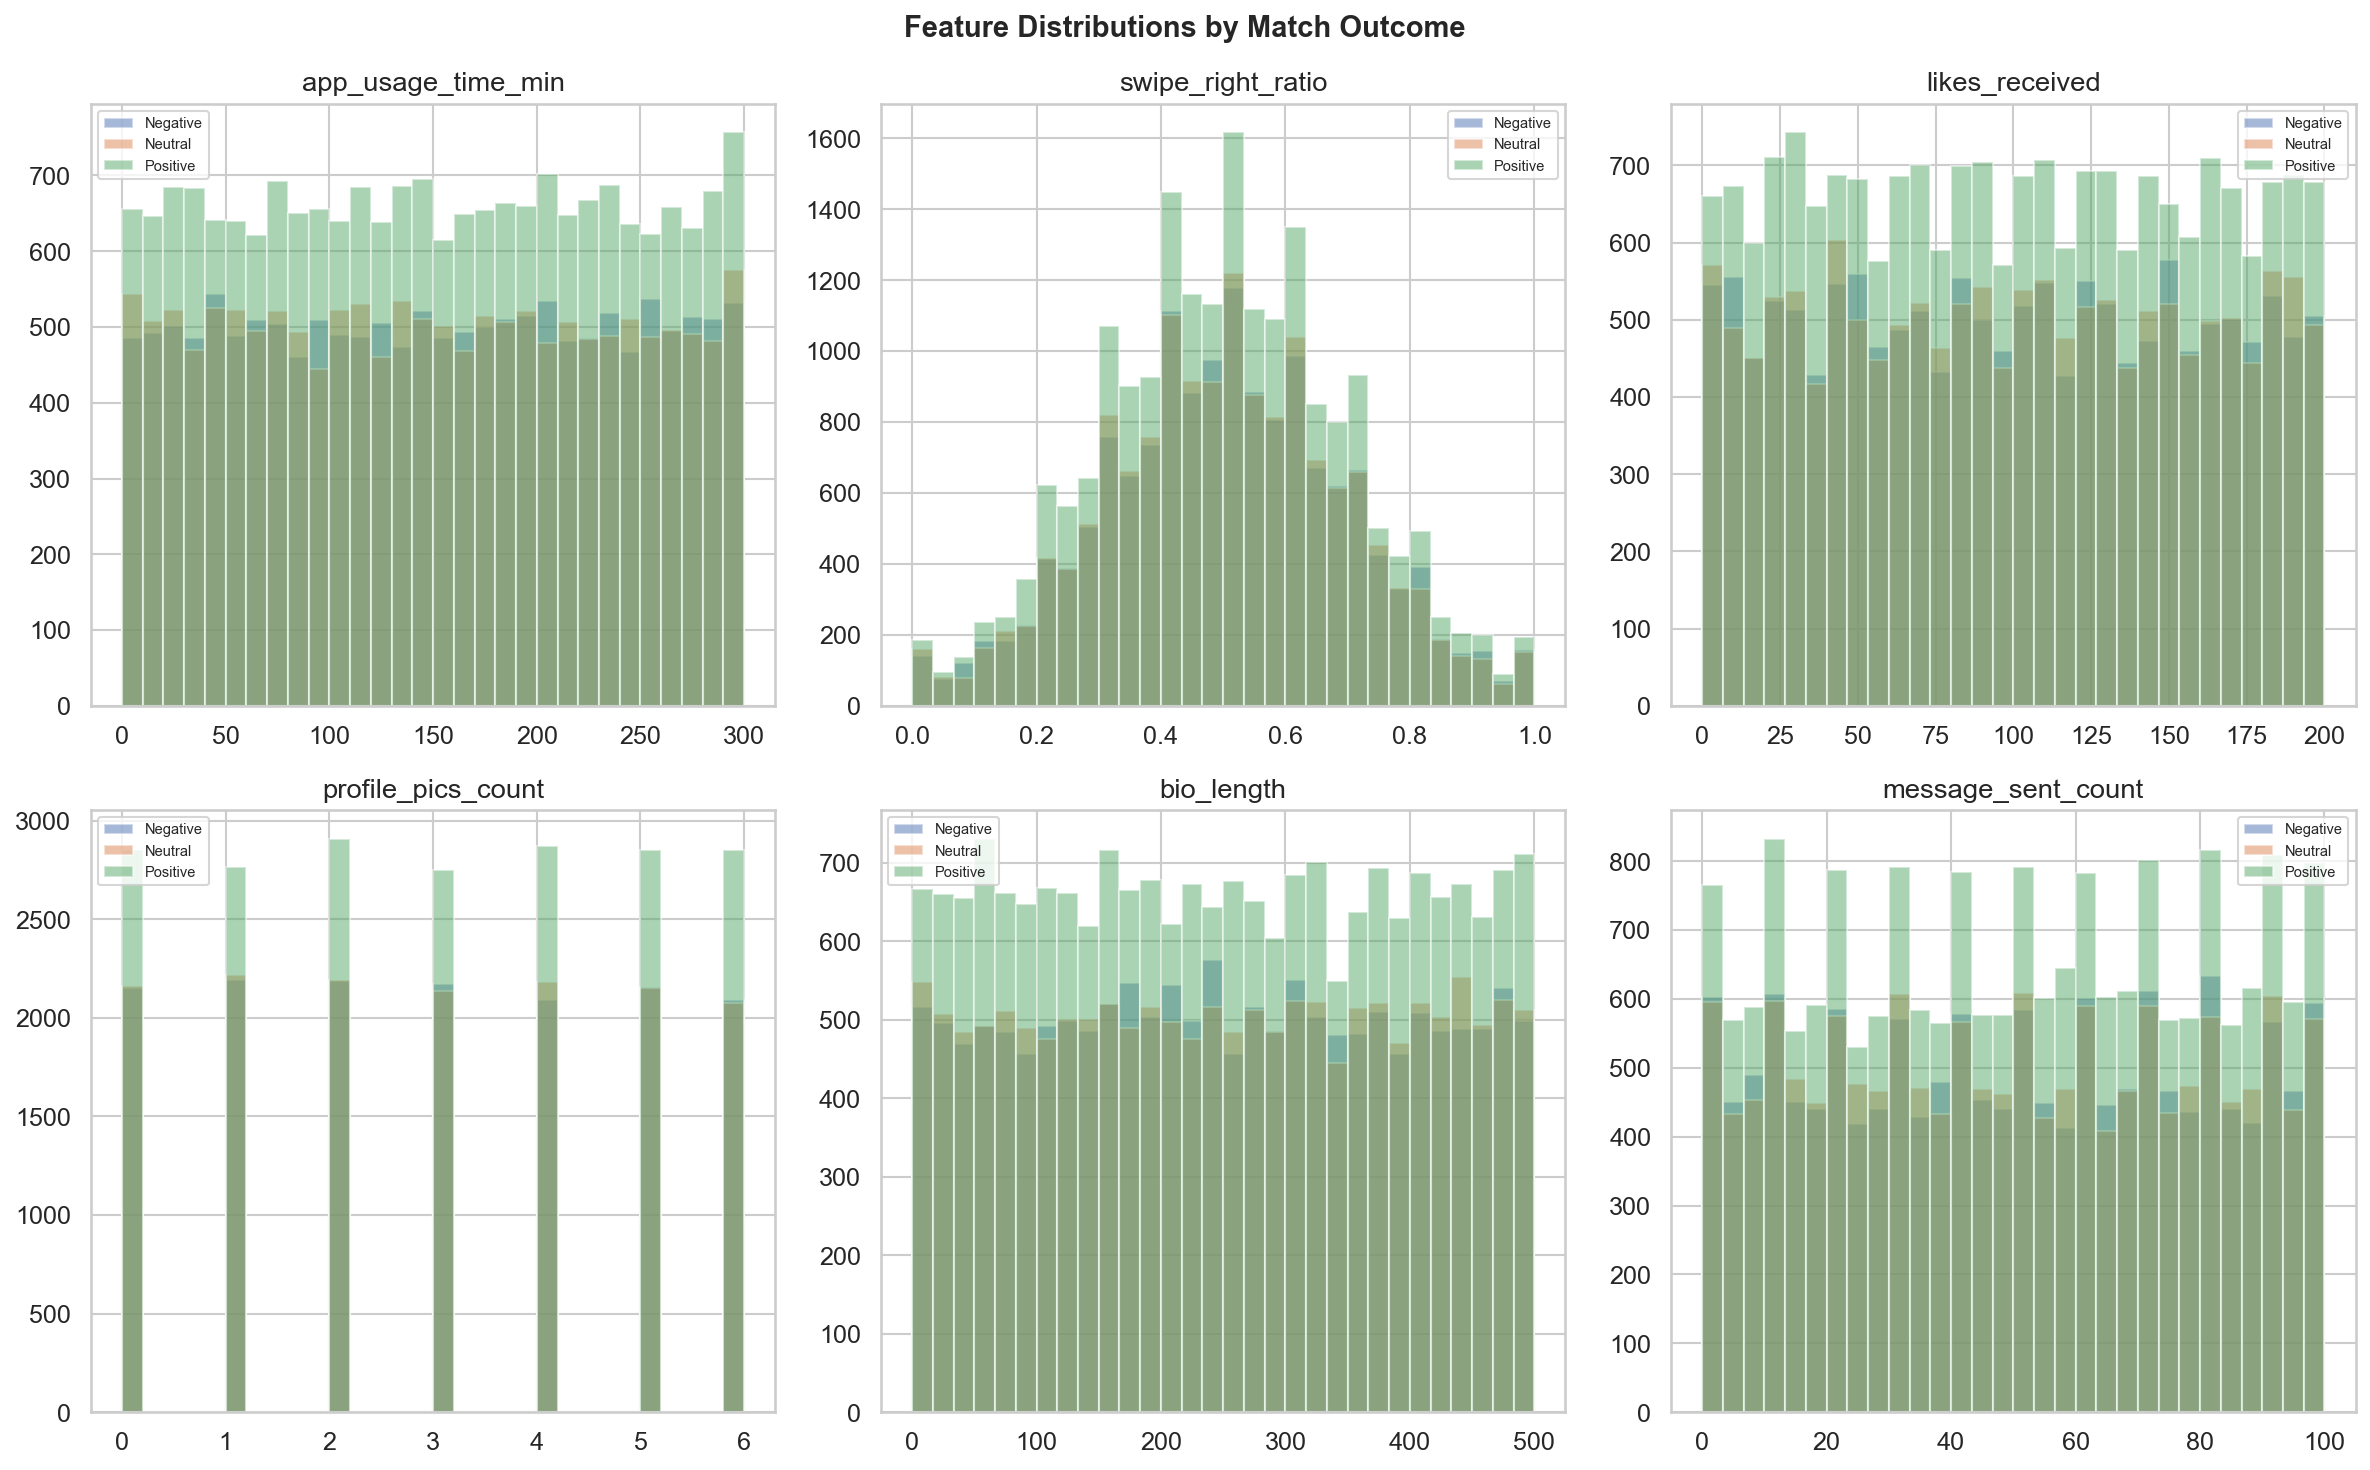

In [13]:
# 4. Feature Distributions by Target Class
selected = NUMERICAL_FEATURES[:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
target_labels = {i: name for i, name in enumerate(CLASS_NAMES)}
for i, col in enumerate(selected):
    for cls_val in sorted(df[TARGET].unique()):
        subset = df[df[TARGET] == cls_val][col]
        axes[i].hist(subset, bins=30, alpha=0.5, label=target_labels[cls_val])
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)
fig.suptitle("Feature Distributions by Match Outcome", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "04_distributions_by_target.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 2. Task 2: Feature Engineering & Selection <a id='task2'></a>

### 2.1 Create New Features

We engineer 5 composite features:
- **EngagementScore** = likes_received + message_sent_count (passive + active interaction)
- **ProfileQuality** = bio_length + 5 × profile_pics_count (profile effort metric)
- **ActivityIntensity** = app_usage_time_min × swipe_right_ratio (engagement × aggressiveness)
- **interest_tags_count** = count of comma-separated interest tags
- **EngagementIntensity** = emoji_usage_rate × message_sent_count (enthusiasm signal)

In [14]:
df["EngagementScore"] = df["likes_received"] + df["message_sent_count"]
df["ProfileQuality"] = df["bio_length"] + 5 * df["profile_pics_count"]
df["ActivityIntensity"] = df["app_usage_time_min"] * df["swipe_right_ratio"]

if "interest_tags" in df.columns:
    df["interest_tags_count"] = df["interest_tags"].apply(
        lambda x: len(str(x).split(',')) if pd.notna(x) else 0
    )

df["EngagementIntensity"] = df["emoji_usage_rate"] * df["message_sent_count"]

# Update feature lists
ENGINEERED_FEATURES = ["EngagementScore", "ProfileQuality", "ActivityIntensity",
                       "interest_tags_count", "EngagementIntensity"]
ALL_NUMERICAL = NUMERICAL_FEATURES + ENGINEERED_FEATURES

print(f"Engineered features added: {ENGINEERED_FEATURES}")
print(f"Total numerical features: {len(ALL_NUMERICAL)}")
df[ENGINEERED_FEATURES].describe()

Engineered features added: ['EngagementScore', 'ProfileQuality', 'ActivityIntensity', 'interest_tags_count', 'EngagementIntensity']
Total numerical features: 13


,EngagementScore,ProfileQuality,ActivityIntensity,interest_tags_count,EngagementIntensity
count,50000.000000,50000.000000,50000.000000,50000.0,50000.000000
mean,149.597980,265.113000,75.062878,3.0,14.345578
std,64.890425,145.220599,55.454516,0.0,12.499390
min,0.000000,0.000000,0.000000,3.0,0.000000
25%,100.000000,140.000000,29.600000,3.0,4.590000
50%,149.000000,265.000000,65.100000,3.0,11.000000
75%,200.000000,391.000000,110.337500,3.0,20.790000
max,300.000000,530.000000,300.000000,3.0,84.600000


### 2.2 Feature Selection using SelectKBest

We use `SelectKBest` with `f_classif` (ANOVA F-test) to select the top 15 features from the combined numerical + one-hot encoded categorical feature space. This reduces dimensionality and removes noisy features.

In [15]:
# Quick preprocessor to demonstrate feature selection
def build_preprocessor():
    numerical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("num", numerical_pipeline, ALL_NUMERICAL),
        ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
    ])

# Fit preprocessor to see all feature names
prep = build_preprocessor()
X_temp = df[ALL_NUMERICAL + CATEGORICAL_FEATURES]
X_temp_transformed = prep.fit_transform(X_temp)

# Get feature names after one-hot encoding
ohe = prep.named_transformers_["cat"].named_steps["encoder"]
cat_names = list(ohe.get_feature_names_out())
all_feature_names = ALL_NUMERICAL + cat_names

# Apply SelectKBest
selector = SelectKBest(score_func=f_classif, k=15)
y_temp = df[TARGET]
selector.fit(X_temp_transformed, y_temp)

# Show selected features and their scores
scores = pd.DataFrame({
    "Feature": all_feature_names,
    "F_Score": selector.scores_,
    "p_value": selector.pvalues_,
    "Selected": selector.get_support()
}).sort_values("F_Score", ascending=False)

print("Top 15 Selected Features (by ANOVA F-score):")
print(scores[scores["Selected"]].to_string(index=False))
print(f"\nTotal features: {len(all_feature_names)} → Selected: {selector.get_support().sum()}")

Top 15 Selected Features (by ANOVA F-score):
               Feature  F_Score  p_value  Selected
            x4_Morning 3.287031 0.037373      True
        x1_Associate’s 2.959824 0.051837      True
                x1_MBA 2.486905 0.083177      True
             x2_Middle 2.267488 0.103583      True
      x4_Early Morning 1.842800 0.158384      True
                x2_Low 1.724476 0.178277      True
     ActivityIntensity 1.722394 0.178649      True
                x1_PhD 1.679832 0.186416      True
    message_sent_count 1.540172 0.214354      True
    profile_pics_count 1.508097 0.221341      True
        x3_Remote Area 1.452619 0.233967      True
       x2_Upper-Middle 1.430342 0.239237      True
x1_No Formal Education 1.338943 0.262132      True
     swipe_right_ratio 1.298550 0.272936      True
           x3_Suburban 1.265375 0.282142      True

Total features: 47 → Selected: 15


### 2.3 Feature Importance (from tree-based models)

After training, we will visualize feature importance from Random Forest and XGBoost (see Section 4).

---
## 3. Task 3: Model Selection & Training <a id='task3'></a>

### 3.1 Train-Test Split (80/20, Stratified)

In [16]:
FEATURE_COLS = ALL_NUMERICAL + CATEGORICAL_FEATURES
X = df[FEATURE_COLS]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nClass distribution (train):")
print(y_train.value_counts().sort_index().rename(lambda i: CLASS_NAMES[i]))
print(f"\nClass distribution (test):")
print(y_test.value_counts().sort_index().rename(lambda i: CLASS_NAMES[i]))

Training set: 40000 samples
Test set:     10000 samples

Class distribution (train):
match_outcome
Negative    12026
Neutral     12094
Positive    15880
Name: count, dtype: int64

Class distribution (test):
match_outcome
Negative    3007
Neutral     3023
Positive    3970
Name: count, dtype: int64


### 3.2 Define Models

We train **7 models + 1 baseline** across different algorithmic families:

| # | Model | Type | Rationale |
---|---|---|---|
| 0 | Dummy Classifier | Baseline | Most-frequent strategy baseline |
| 1 | Logistic Regression | Linear | Strong linear baseline |
| 2 | Decision Tree | Rule-based | Interpretable, non-linear |
| 3 | Random Forest | Bagging Ensemble | Variance reduction |
| 4 | XGBoost | Boosting Ensemble | State-of-the-art performance |
| 5 | SVM (LinearSVC) | Margin-based | High-dimensional boundaries |
| 6 | MLP Neural Network | Deep Learning | Non-linear interactions |
| 7 | Voting Classifier | Ensemble | Soft voting (LR + RF + XGB) |

In [17]:
preprocessor = build_preprocessor()

models_and_params = [
    ("Dummy (Baseline)", DummyClassifier(strategy="most_frequent"), {}),
    ("Logistic Regression", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
     {"C": [0.01, 0.1, 1.0, 10.0, 100.0]}),
    ("Decision Tree", DecisionTreeClassifier(class_weight="balanced", random_state=42),
     {"max_depth": [10, 20, 30, None], "min_samples_split": [2, 5, 10, 20], "min_samples_leaf": [1, 5, 10]}),
    ("Random Forest", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=1),
     {"n_estimators": [100, 200, 300], "max_depth": [10, 20, 30, None], "min_samples_split": [2, 5, 10]}),
    ("XGBoost", XGBClassifier(eval_metric="mlogloss", random_state=42, n_jobs=1),
     {"learning_rate": [0.01, 0.05, 0.1, 0.2], "max_depth": [3, 5, 7, 10],
      "n_estimators": [100, 200, 300], "subsample": [0.8, 1.0]}),
    ("SVM", LinearSVC(class_weight="balanced", random_state=42, max_iter=1000),
     {"C": [0.01, 0.1, 1.0, 10.0]}),
    ("Neural Network (MLP)", MLPClassifier(activation="relu", max_iter=500, random_state=42,
                                           early_stopping=True, validation_fraction=0.1),
     {"hidden_layer_sizes": [(64, 32), (128, 64), (128, 64, 32)],
      "alpha": [0.0001, 0.001, 0.01], "learning_rate_init": [0.001, 0.01]}),
]

print(f"Defined {len(models_and_params)} models for training.")

Defined 7 models for training.


### 3.3 Train All Models with Hyperparameter Tuning (Task 5: RandomizedSearchCV)

Each model is wrapped in a pipeline: `Preprocessor → SelectKBest(k=15) → Model`

Hyperparameter tuning uses `RandomizedSearchCV` with:
- `n_iter=10` random combinations
- `cv=3` fold cross-validation
- `scoring='f1_weighted'` (optimizes for balanced F1 across all 3 classes)

In [18]:
fitted_models = {}

for name, estimator, param_grid in models_and_params:
    print(f"\n{'='*60}")
    print(f"  Training: {name}")
    print(f"{'='*60}")

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("selector", SelectKBest(score_func=f_classif, k=15)),
        ("model", estimator),
    ])

    if param_grid:
        grid = RandomizedSearchCV(
            pipe,
            param_distributions={f"model__{k}": v for k, v in param_grid.items()},
            n_iter=10, cv=3, scoring="f1_weighted",
            n_jobs=-1, verbose=0, random_state=42,
        )
        grid.fit(X_train, y_train)
        best_pipe = grid.best_estimator_
        print(f"  Best params: {grid.best_params_}")
        print(f"  Best CV F1:  {grid.best_score_:.4f}")
    else:
        pipe.fit(X_train, y_train)
        best_pipe = pipe

    fitted_models[name] = best_pipe
    joblib.dump(best_pipe, os.path.join(MODELS_DIR, name.lower().replace(" ", "_").replace("(", "").replace(")", "") + ".pkl"))

print("\n" + "="*60)
print("  Training Voting Classifier (Ensemble)")
print("="*60)

# Build Voting Classifier from best individual models
estimators = [
    ("lr", fitted_models["Logistic Regression"].named_steps["model"]),
    ("rf", fitted_models["Random Forest"].named_steps["model"]),
    ("xgb", fitted_models["XGBoost"].named_steps["model"]),
]
voting_clf = VotingClassifier(estimators=estimators, voting="soft")
voting_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("selector", SelectKBest(score_func=f_classif, k=15)),
    ("model", voting_clf),
])
voting_pipe.fit(X_train, y_train)
fitted_models["Voting Classifier"] = voting_pipe
joblib.dump(voting_pipe, os.path.join(MODELS_DIR, "voting_classifier.pkl"))

print(f"\nAll {len(fitted_models)} models trained and saved.")


  Training: Dummy (Baseline)

  Training: Logistic Regression
  Best params: {'model__C': 0.1}
  Best CV F1:  0.3317

  Training: Decision Tree
  Best params: {'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': None}
  Best CV F1:  0.3370

  Training: Random Forest
  Best params: {'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__max_depth': 20}
  Best CV F1:  0.3416

  Training: XGBoost
  Best params: {'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 10, 'model__learning_rate': 0.2}
  Best CV F1:  0.3381

  Training: SVM
  Best params: {'model__C': 10.0}
  Best CV F1:  0.2817

  Training: Neural Network (MLP)
  Best params: {'model__learning_rate_init': 0.01, 'model__hidden_layer_sizes': (128, 64, 32), 'model__alpha': 0.0001}
  Best CV F1:  0.2370

  Training Voting Classifier (Ensemble)

All 8 models trained and saved.


---
## 4. Task 4: Model Evaluation & Comparison <a id='task4'></a>

### 4.1 Evaluate All Models

Metrics computed:
- **Accuracy:** Overall correctness
- **Precision (weighted):** Positive predictive value
- **Recall (weighted):** Sensitivity
- **F1 (weighted):** Harmonic mean of precision & recall
- **ROC-AUC (OvR):** Area under ROC curve (One-vs-Rest)

In [19]:
classes = sorted(y_test.unique().tolist())
results = []

for name, model in fitted_models.items():
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    try:
        y_prob = model.predict_proba(X_test)
        y_test_bin = label_binarize(y_test, classes=classes)
        roc = roc_auc_score(y_test_bin, y_prob, average="weighted", multi_class="ovr")
    except Exception:
        roc = np.nan

    results.append({
        "Model": name, "Accuracy": round(acc, 4), "Precision": round(prec, 4),
        "Recall": round(rec, 4), "F1_Weighted": round(f1, 4),
        "ROC_AUC": round(roc, 4) if not np.isnan(roc) else "N/A",
    })

    print(f"\n{'='*60}\n  {name}\n{'='*60}")
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))

# Build comparison table
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values("F1_Weighted", ascending=False).reset_index(drop=True)
comparison_df.index += 1
comparison_df.index.name = "Rank"
comparison_df.to_csv(os.path.join(REPORTS_DIR, "model_comparison.csv"))
print("\nModel Comparison Table (sorted by F1 Weighted):")
comparison_df


  Dummy (Baseline)
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00      3007
     Neutral       0.00      0.00      0.00      3023
    Positive       0.40      1.00      0.57      3970

    accuracy                           0.40     10000
   macro avg       0.13      0.33      0.19     10000
weighted avg       0.16      0.40      0.23     10000


  Logistic Regression
              precision    recall  f1-score   support

    Negative       0.29      0.35      0.32      3007
     Neutral       0.30      0.30      0.30      3023
    Positive       0.40      0.33      0.36      3970

    accuracy                           0.33     10000
   macro avg       0.33      0.33      0.33     10000
weighted avg       0.34      0.33      0.33     10000


  Decision Tree
              precision    recall  f1-score   support

    Negative       0.31      0.34      0.32      3007
     Neutral       0.30      0.31      0.31      3023
    Positive   

,Model,Accuracy,Precision,Recall,F1_Weighted,ROC_AUC
Rank,,,,,,
1,XGBoost,0.3579,0.3494,0.3579,0.3503,0.5093
2,Voting Classifier,0.3553,0.3458,0.3553,0.3466,0.5096
3,Random Forest,0.3541,0.3449,0.3541,0.3460,0.5057
4,Decision Tree,0.3371,0.3404,0.3371,0.3382,0.4996
5,Logistic Regression,0.3293,0.3361,0.3293,0.3307,0.4994
6,SVM,0.3895,0.3417,0.3895,0.2609,N/A
7,Dummy (Baseline),0.3970,0.1576,0.3970,0.2256,0.5
8,Neural Network (MLP),0.3968,0.1576,0.3968,0.2256,0.5013


### 4.2 Confusion Matrices

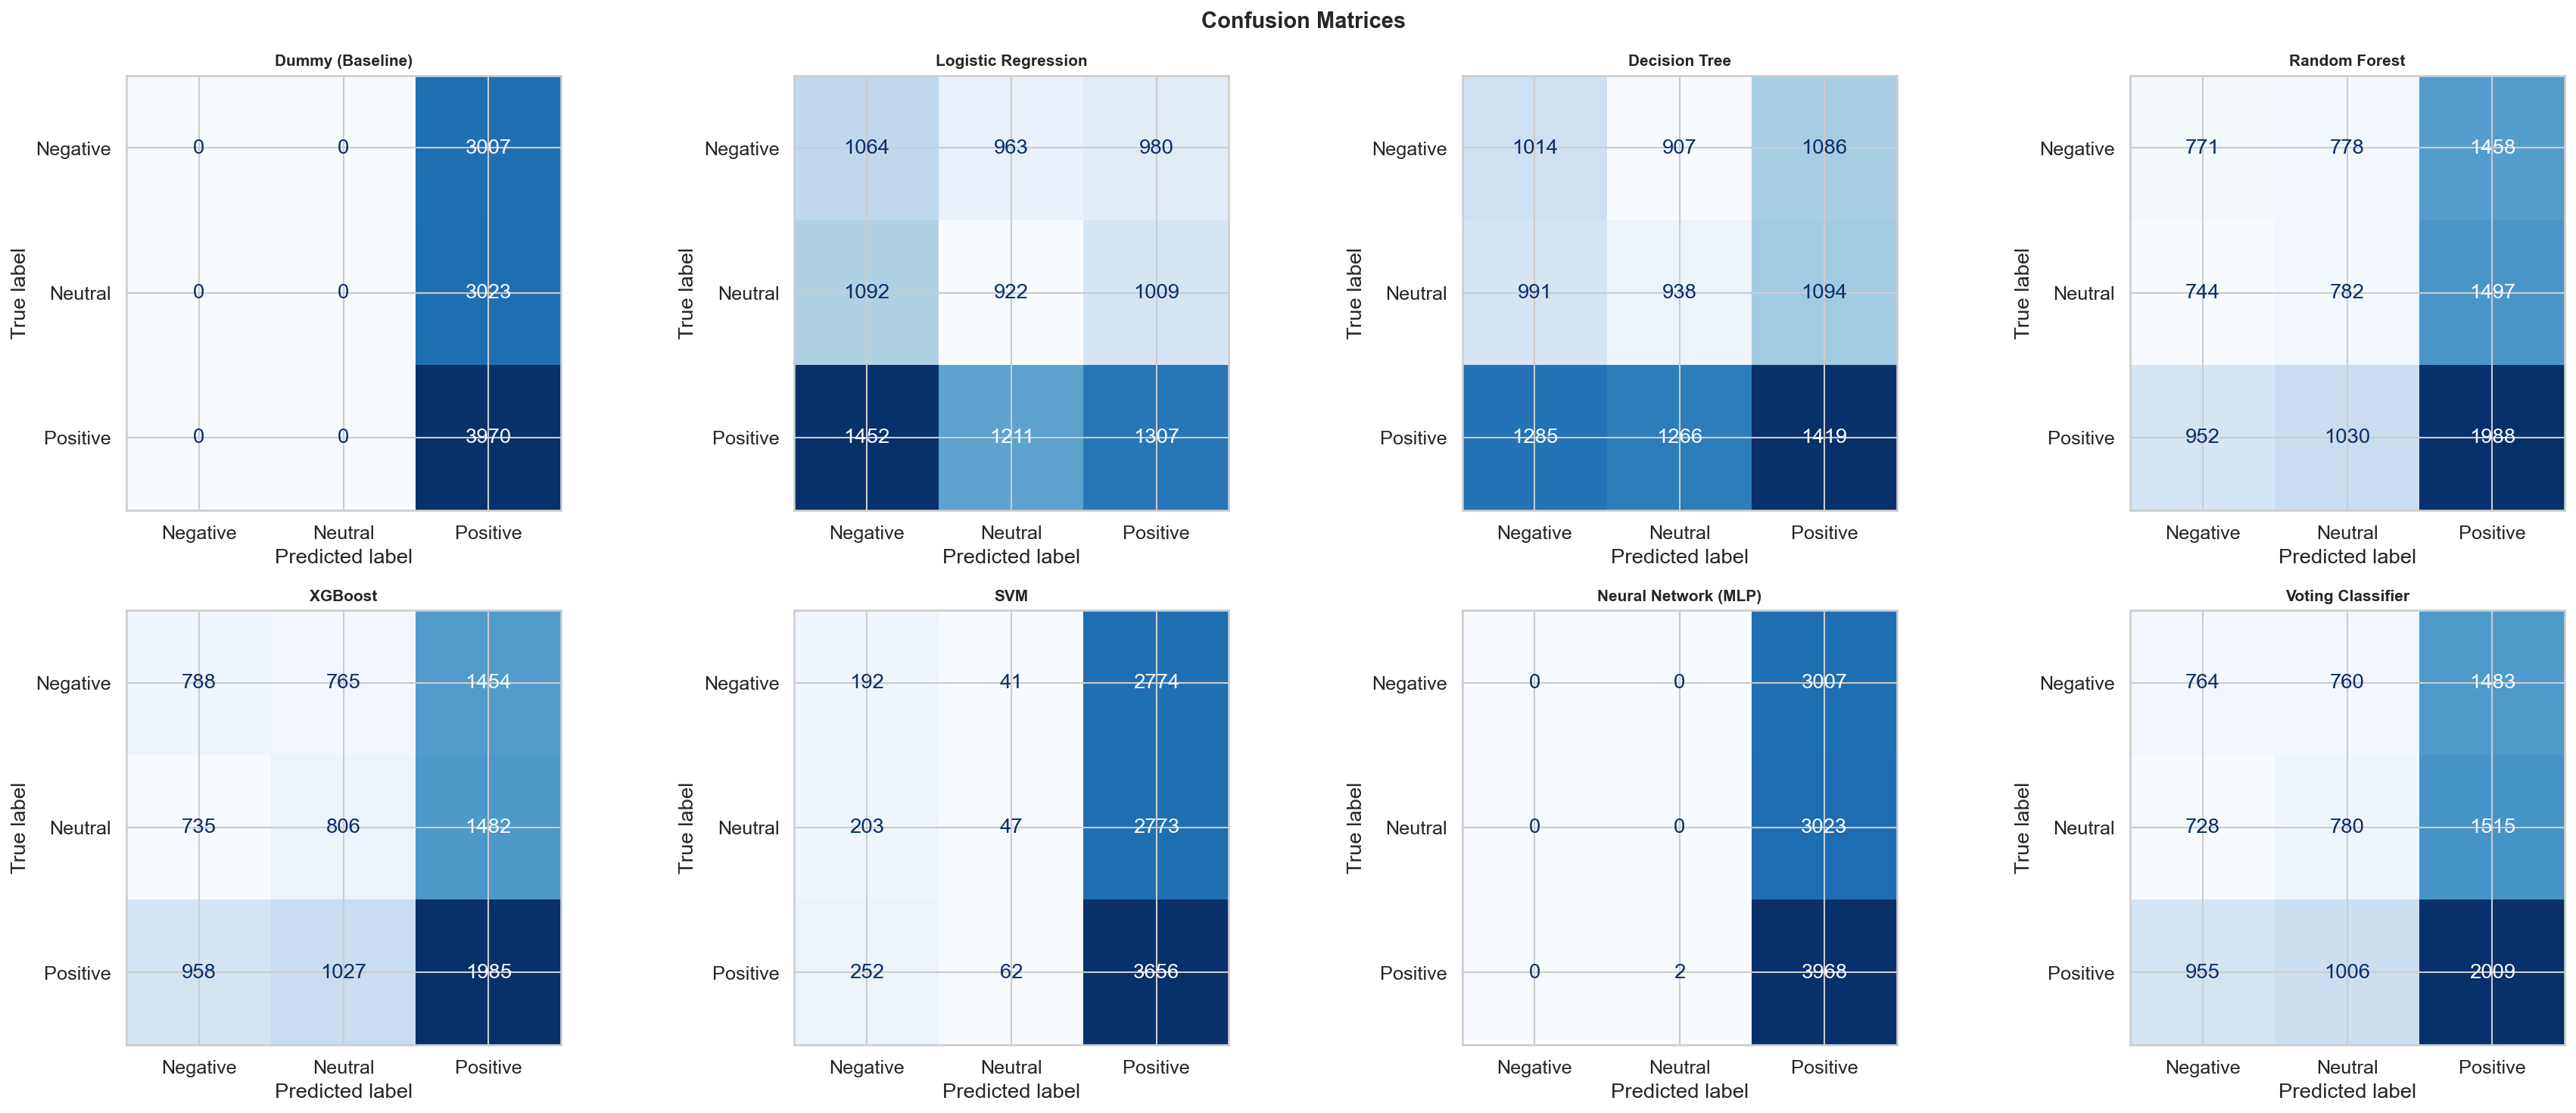

In [20]:
n = len(fitted_models)
fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(6 * ((n + 1) // 2), 10))
axes = axes.flatten()
for i, (name, model) in enumerate(fitted_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=axes[i], cmap="Blues", colorbar=False, values_format="d")
    axes[i].set_title(name, fontsize=10, fontweight="bold")
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "05_confusion_matrices.png"), dpi=150, bbox_inches="tight")
plt.show()

### 4.3 ROC Curves (One-vs-Rest)

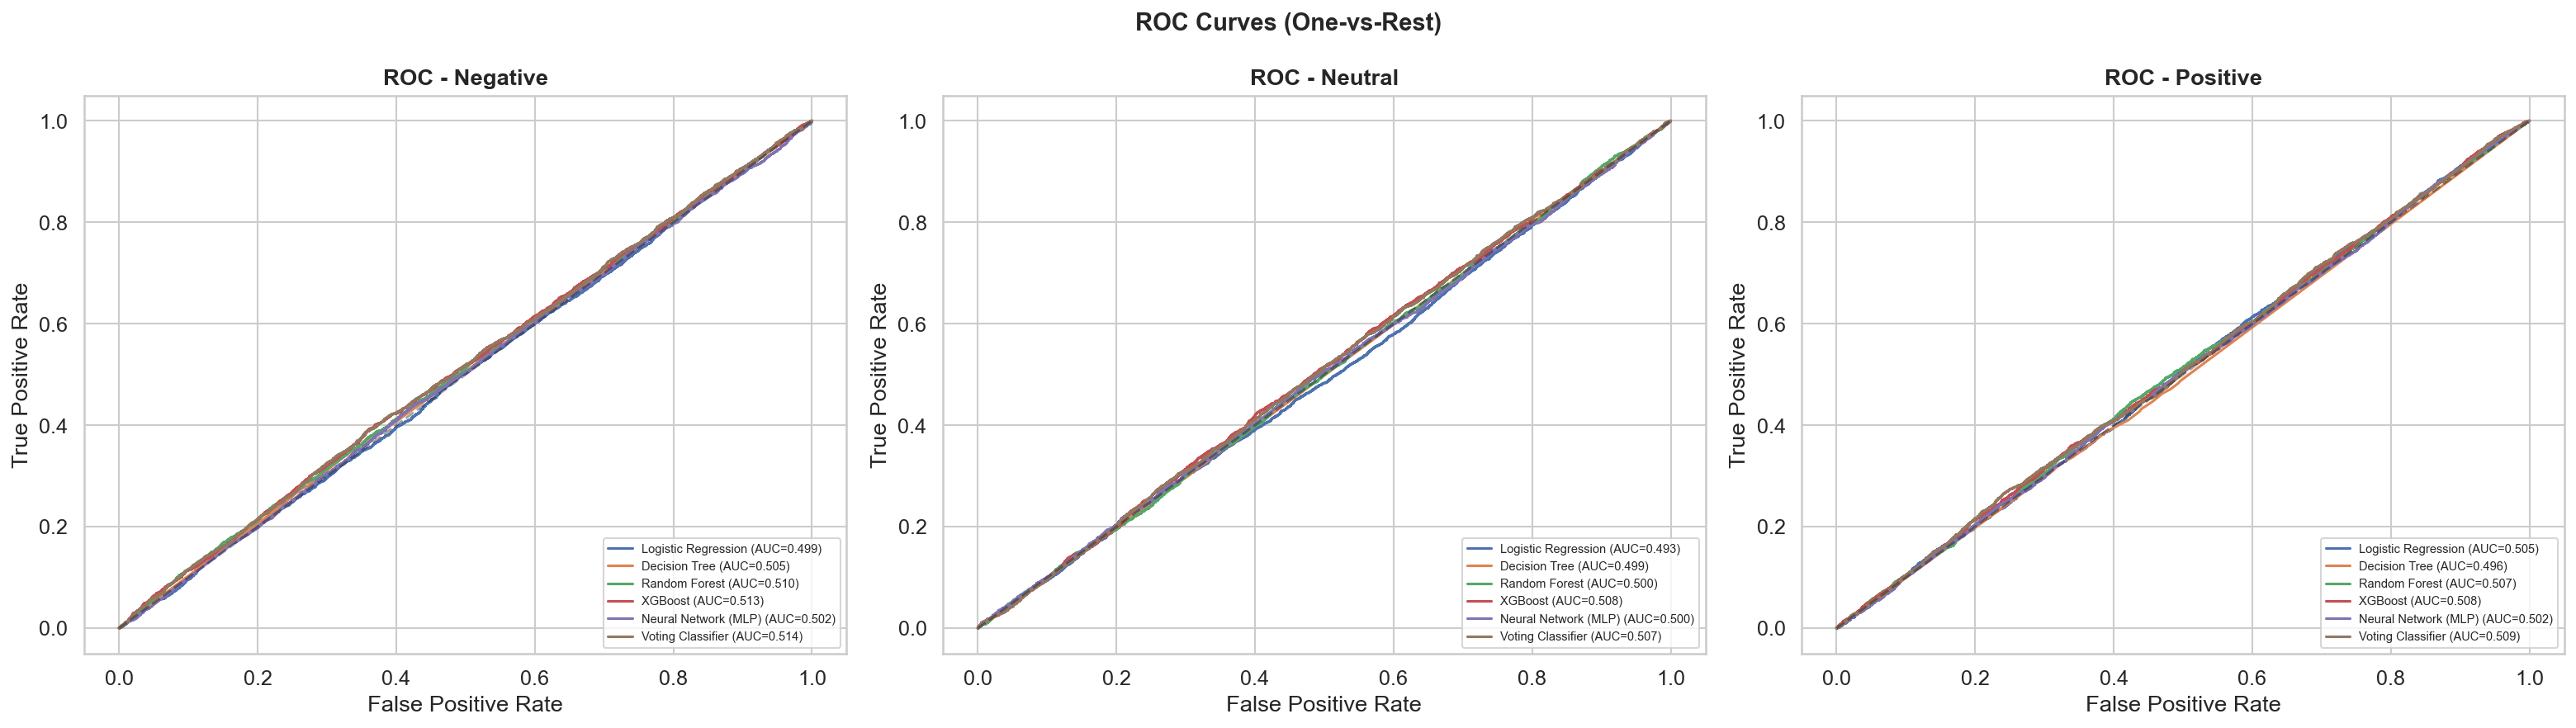

In [21]:
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = len(classes)

fig, axes = plt.subplots(1, n_classes, figsize=(7 * n_classes, 6))
if n_classes == 1:
    axes = [axes]

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    ax = axes[cls_idx]
    for name, model in fitted_models.items():
        if name == "Dummy (Baseline)":
            continue
        try:
            y_prob = model.predict_proba(X_test)
            fpr, tpr, _ = roc_curve(y_test_bin[:, cls_idx], y_prob[:, cls_idx])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
        except Exception:
            continue
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax.set_title(f"ROC - {cls_name}", fontweight="bold")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=7, loc="lower right")
fig.suptitle("ROC Curves (One-vs-Rest)", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "06_roc_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

### 4.4 Model Comparison Bar Chart

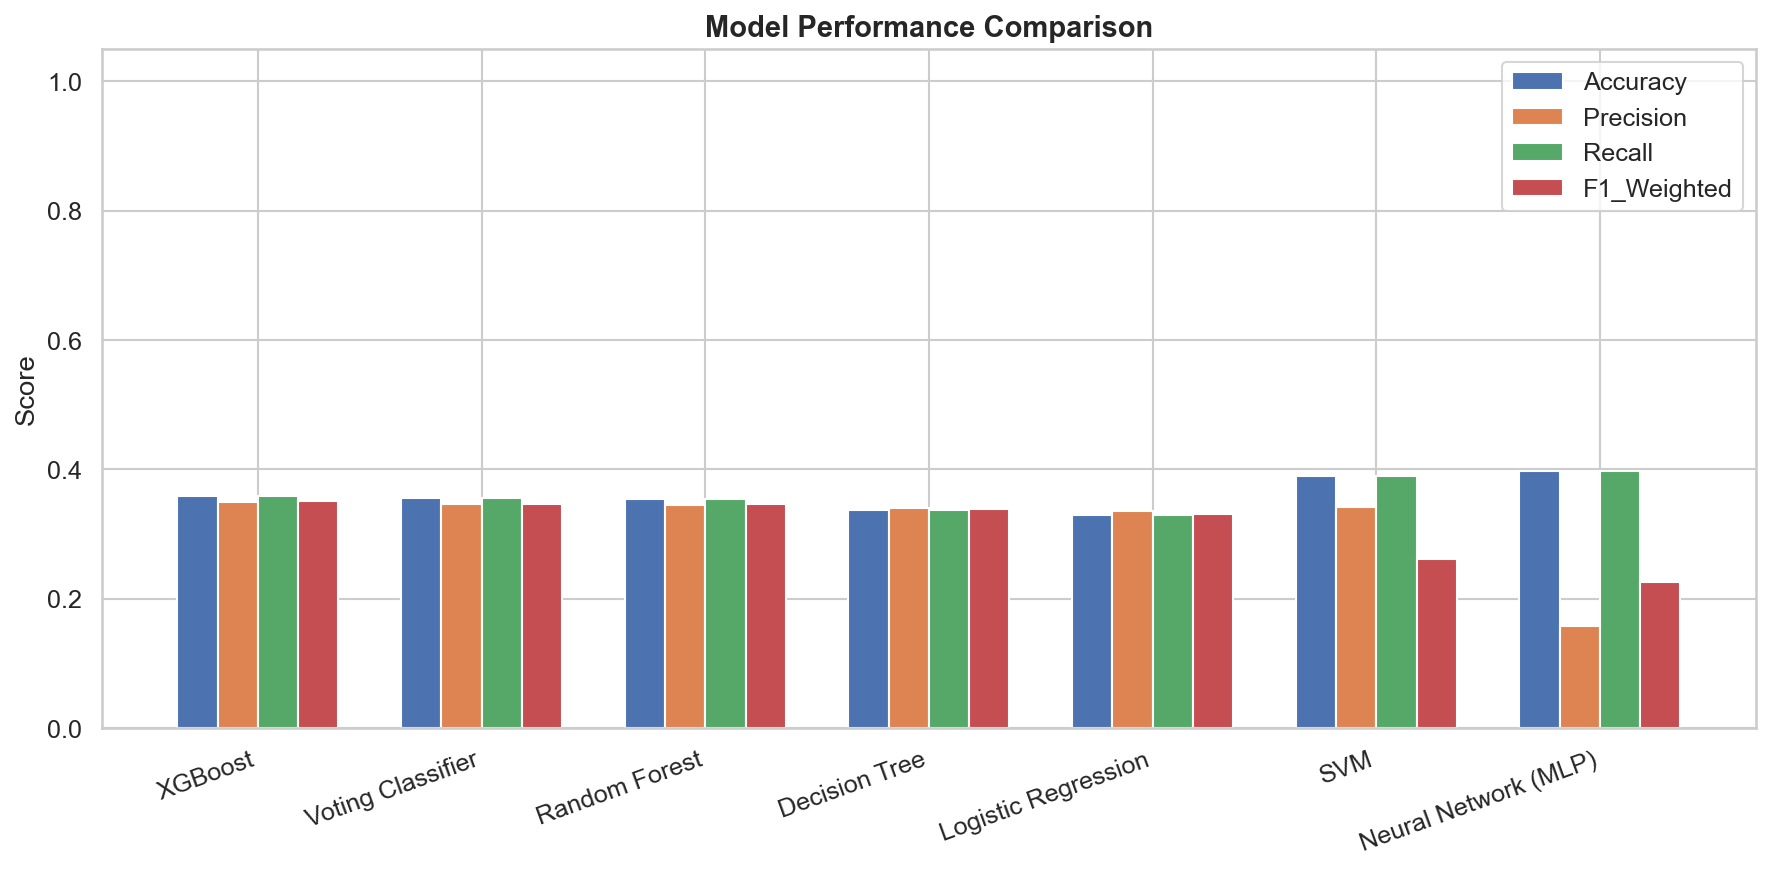

In [22]:
metrics = ["Accuracy", "Precision", "Recall", "F1_Weighted"]
df_plot = comparison_df[comparison_df["Model"] != "Dummy (Baseline)"].copy()

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(df_plot))
width = 0.18
for i, m in enumerate(metrics):
    vals = pd.to_numeric(df_plot[m], errors="coerce")
    ax.bar(x + i * width, vals, width, label=m)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_plot["Model"], rotation=20, ha="right")
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison", fontsize=14, fontweight="bold")
ax.legend()
ax.set_ylim(0, 1.05)
fig.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "07_model_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

### 4.5 Feature Importance (Random Forest & XGBoost)

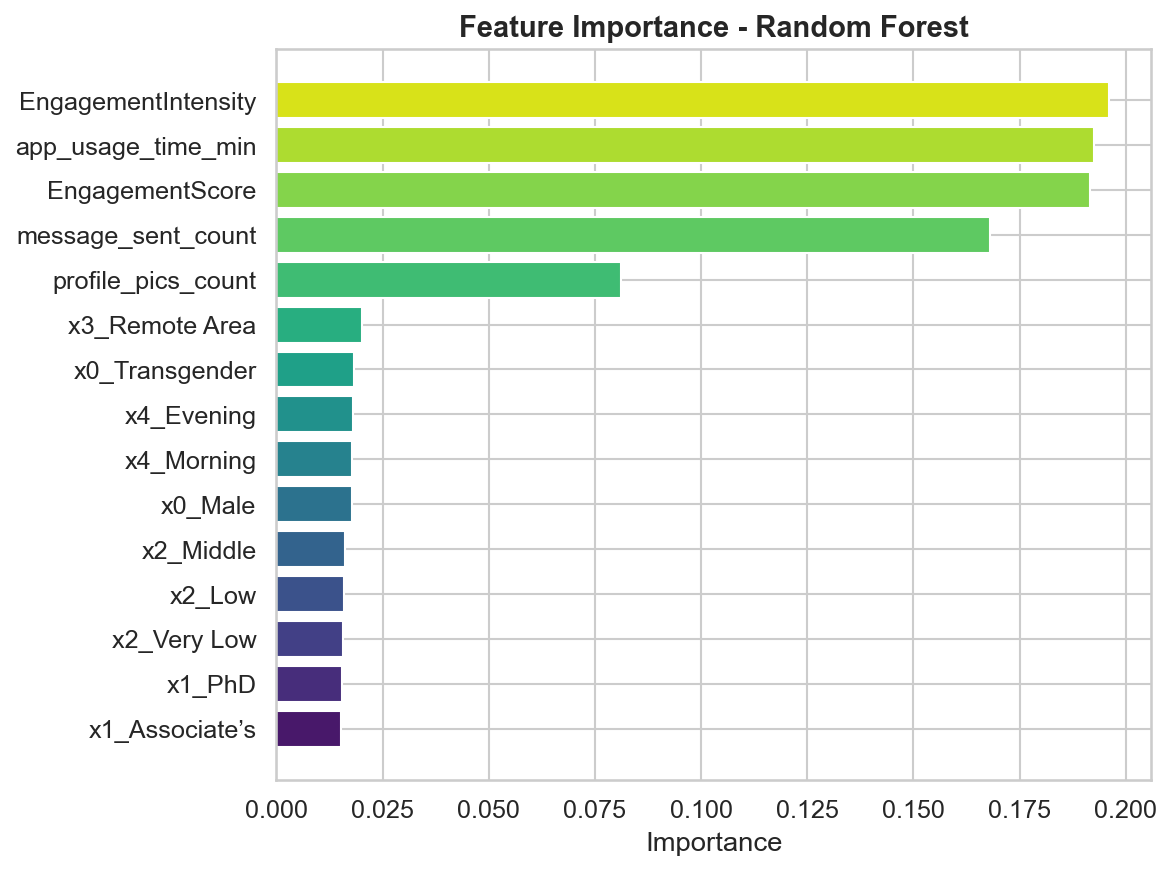

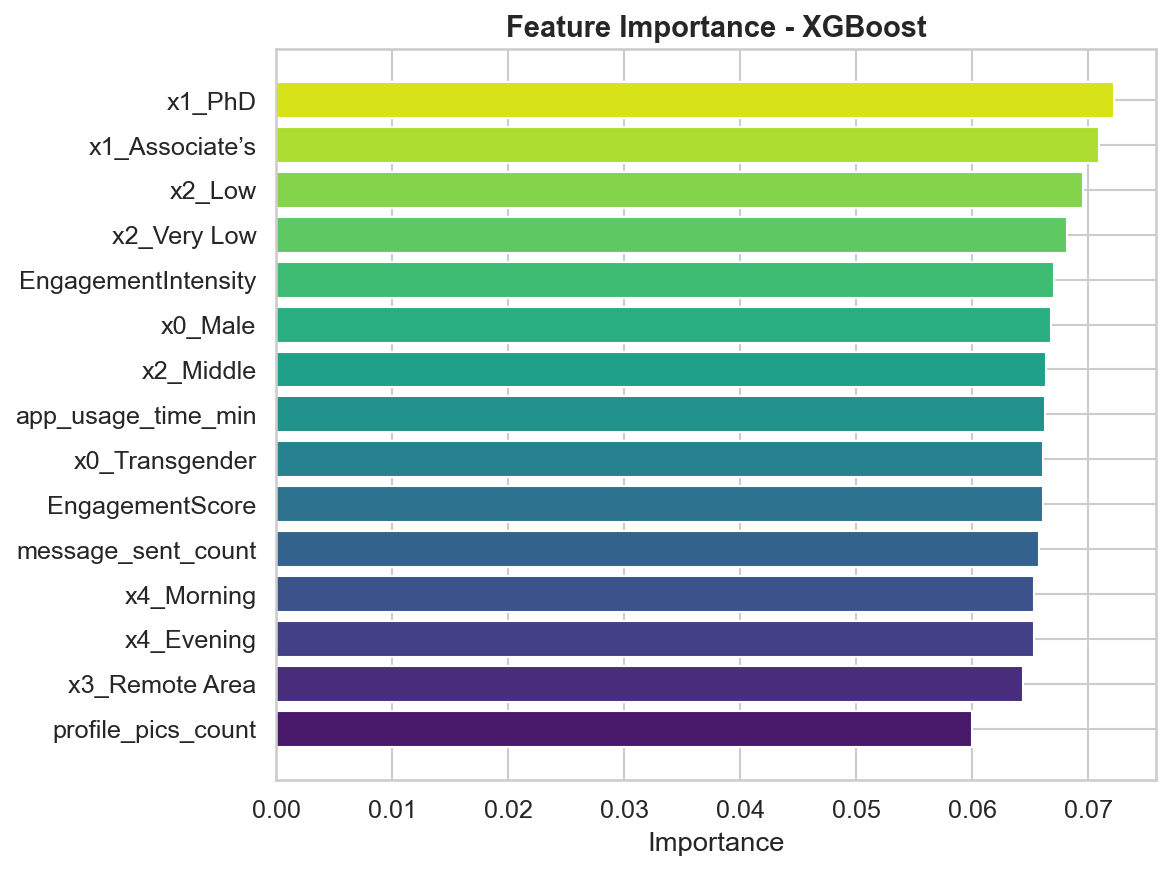

In [23]:
for model_name in ["Random Forest", "XGBoost"]:
    model = fitted_models.get(model_name)
    if model is None:
        continue

    clf = model.named_steps["model"]
    importances = clf.feature_importances_

    # Get feature names
    prep = model.named_steps["preprocessor"]
    try:
        ohe = prep.named_transformers_["cat"].named_steps["encoder"]
        cat_names_local = list(ohe.get_feature_names_out())
    except Exception:
        cat_names_local = []
    num_names = list(prep.transformers_[0][2])
    all_names = num_names + cat_names_local

    selector = model.named_steps.get("selector")
    if selector is not None:
        mask = selector.get_support()
        all_names = [n for n, m in zip(all_names, mask) if m]

    if len(all_names) != len(importances):
        all_names = [f"f{i}" for i in range(len(importances))]

    idx = np.argsort(importances)[-15:]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(range(len(idx)), importances[idx], color=sns.color_palette(PALETTE, len(idx)))
    ax.set_yticks(range(len(idx)))
    ax.set_yticklabels([all_names[i] for i in idx])
    ax.set_title(f"Feature Importance - {model_name}", fontsize=14, fontweight="bold")
    ax.set_xlabel("Importance")
    fig.tight_layout()
    fname = f"08_feature_importance_{model_name.lower().replace(' ', '_')}.png"
    plt.savefig(os.path.join(VIZ_DIR, fname), dpi=150, bbox_inches="tight")
    plt.show()

### 4.6 Learning Curves (Overfitting Analysis)

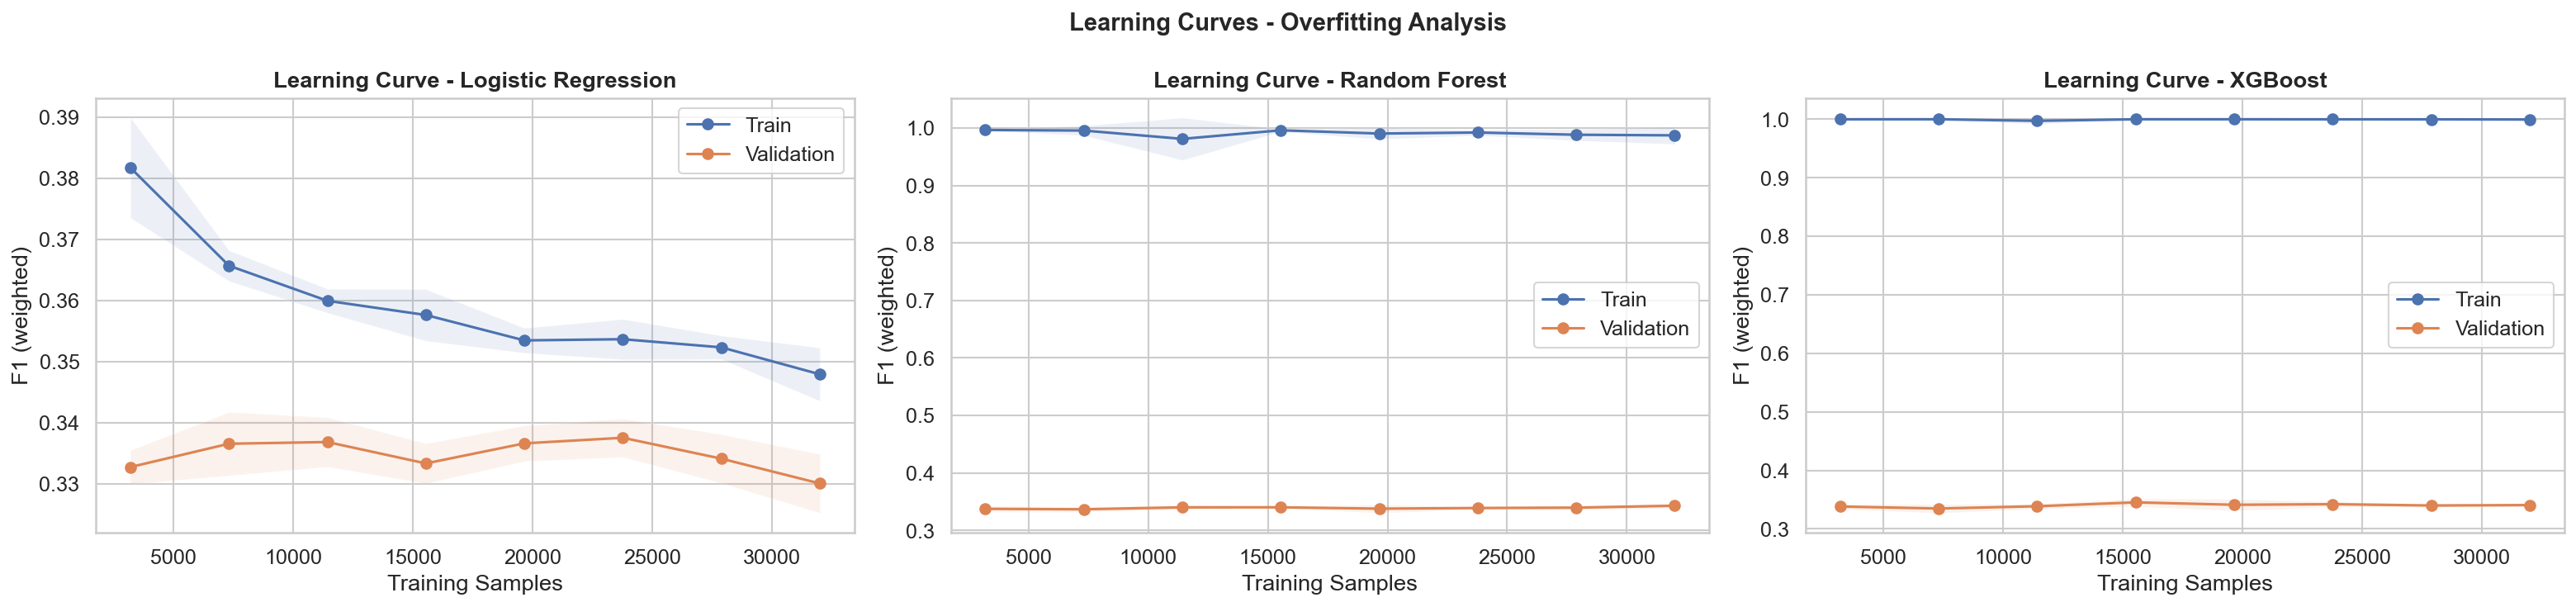

In [24]:
selected_models = ["Logistic Regression", "Random Forest", "XGBoost"]
fig, axes = plt.subplots(1, len(selected_models), figsize=(7 * len(selected_models), 5))

for i, name in enumerate(selected_models):
    model = fitted_models.get(name)
    if model is None:
        continue
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train, cv=5,
        scoring="f1_weighted",
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1,
    )
    axes[i].plot(train_sizes, train_scores.mean(axis=1), "o-", label="Train")
    axes[i].plot(train_sizes, val_scores.mean(axis=1), "o-", label="Validation")
    axes[i].fill_between(train_sizes,
                         train_scores.mean(axis=1) - train_scores.std(axis=1),
                         train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1)
    axes[i].fill_between(train_sizes,
                         val_scores.mean(axis=1) - val_scores.std(axis=1),
                         val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.1)
    axes[i].set_title(f"Learning Curve - {name}", fontweight="bold")
    axes[i].set_xlabel("Training Samples")
    axes[i].set_ylabel("F1 (weighted)")
    axes[i].legend()
fig.suptitle("Learning Curves - Overfitting Analysis", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "09_learning_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

### 4.7 SHAP Explainability (XGBoost & Random Forest)

<Figure size 1800x1200 with 0 Axes>

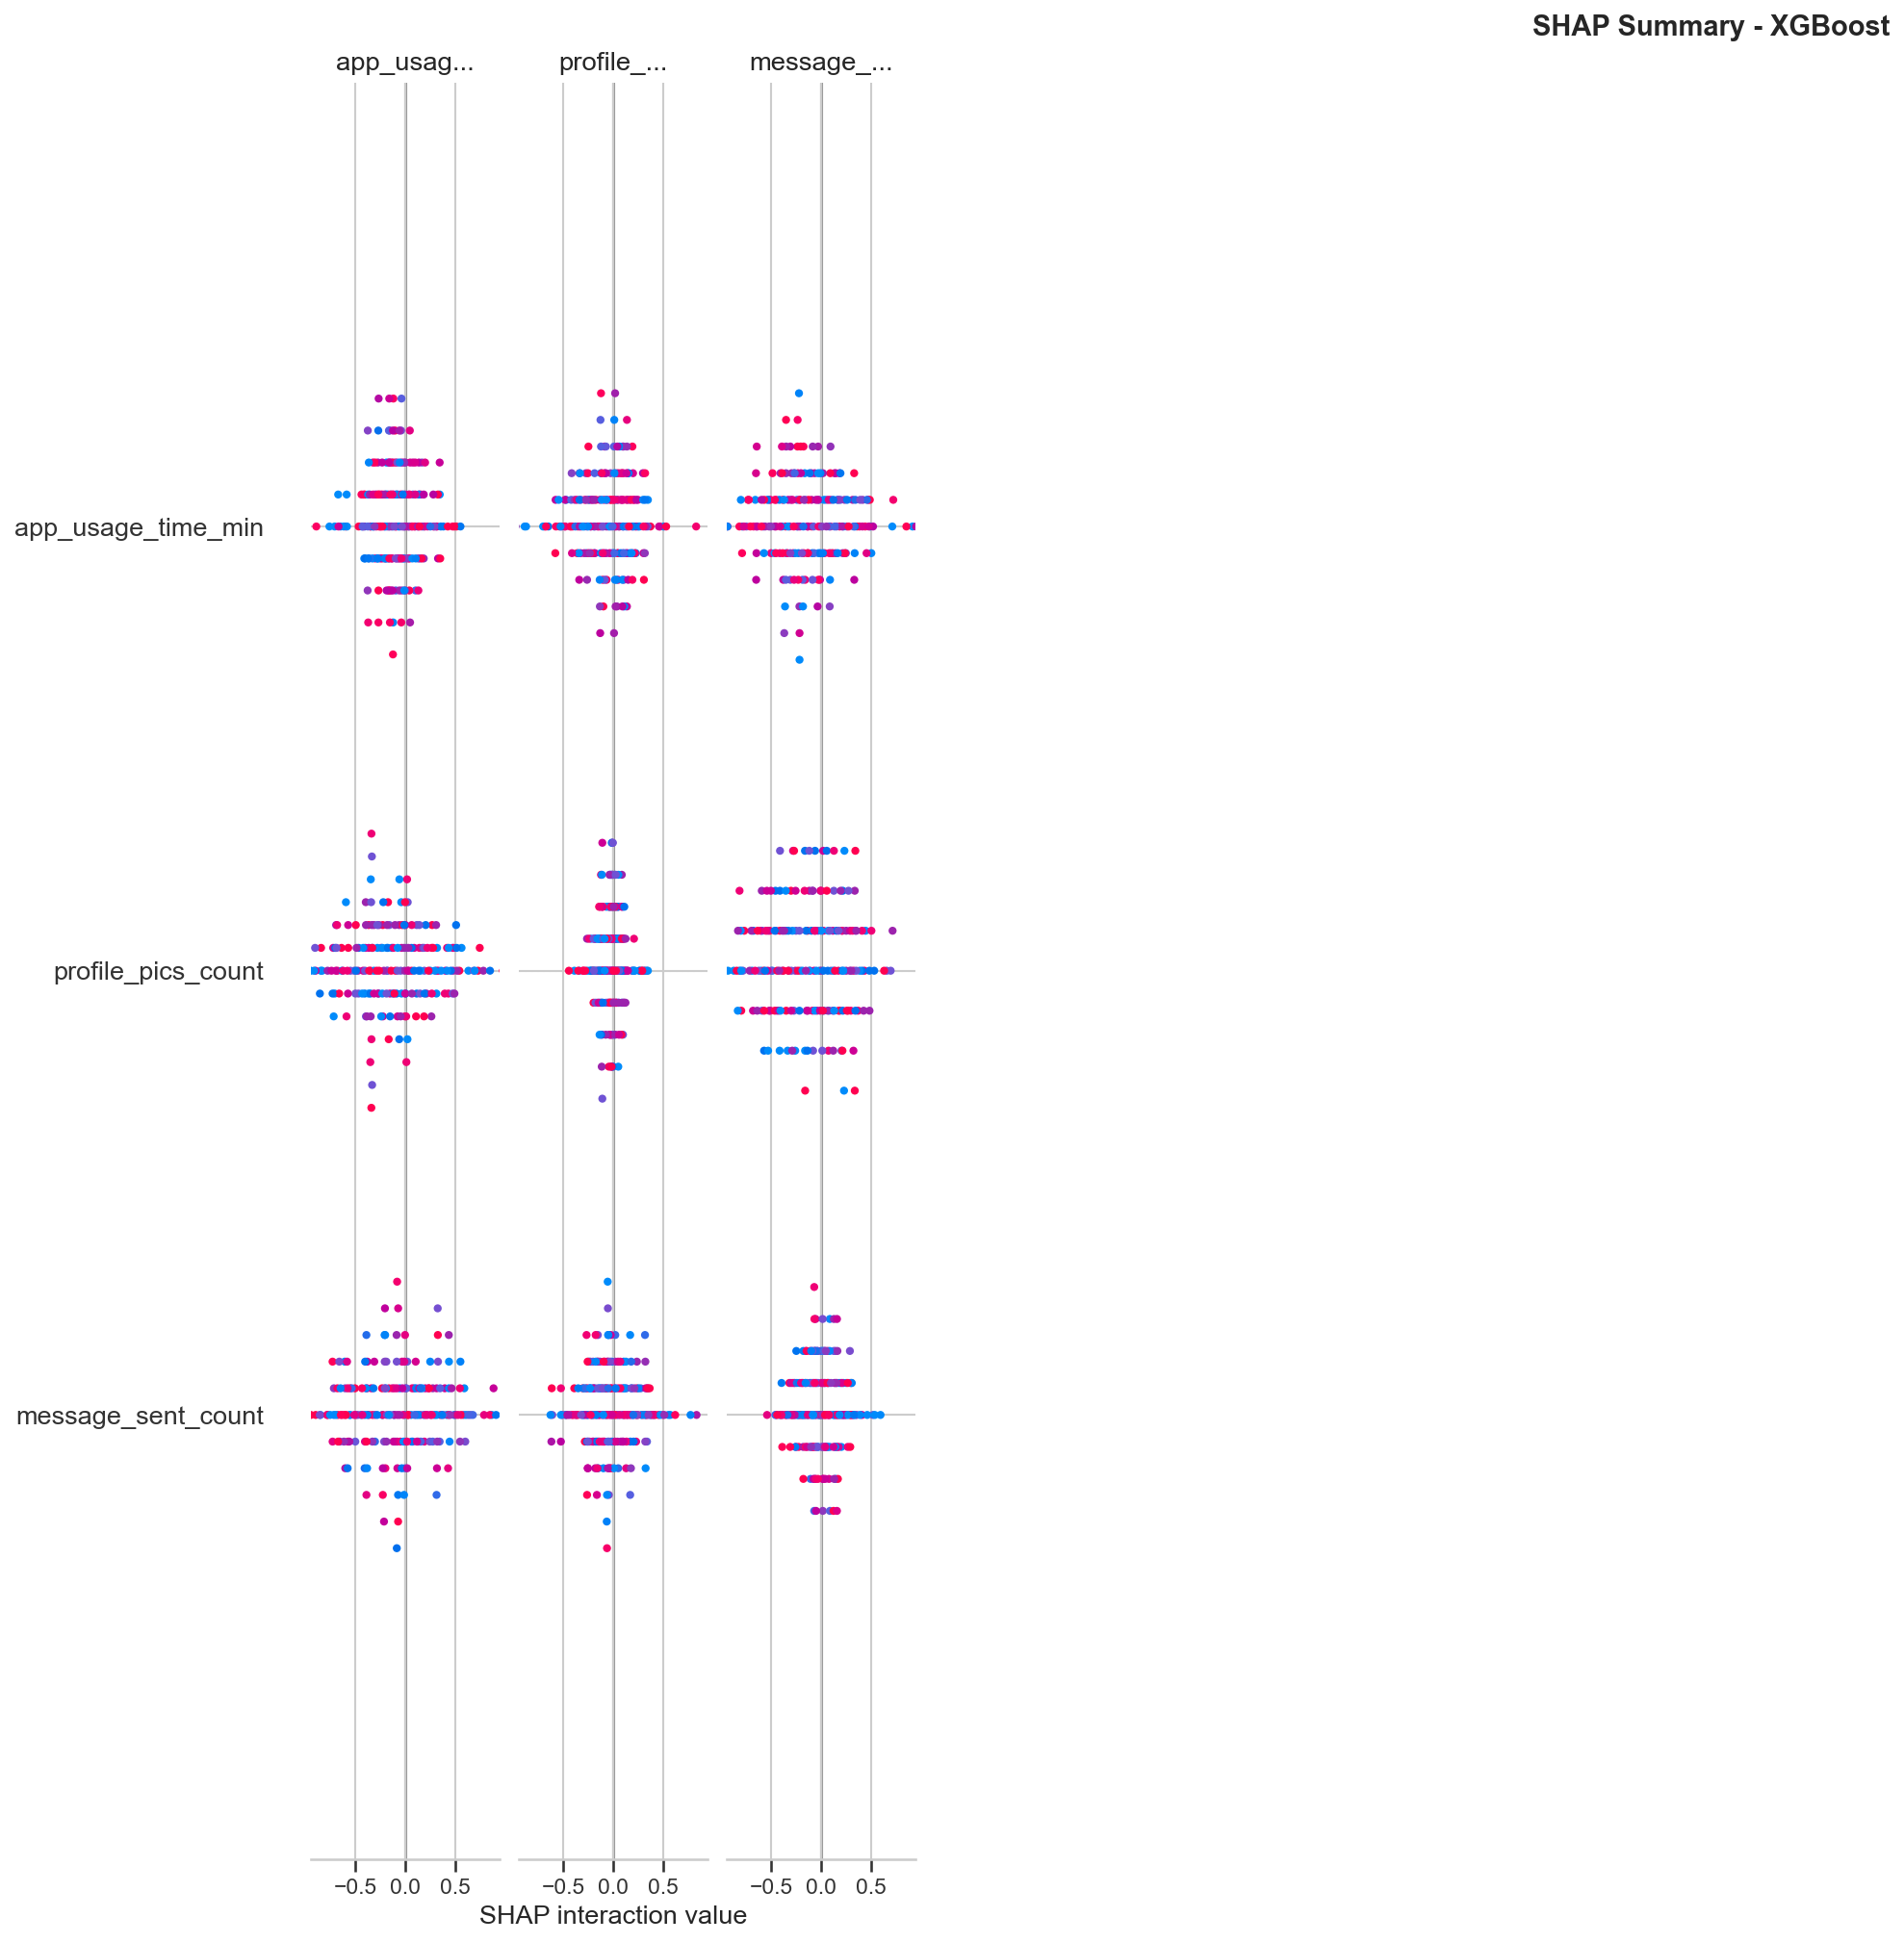

<Figure size 1800x1200 with 0 Axes>

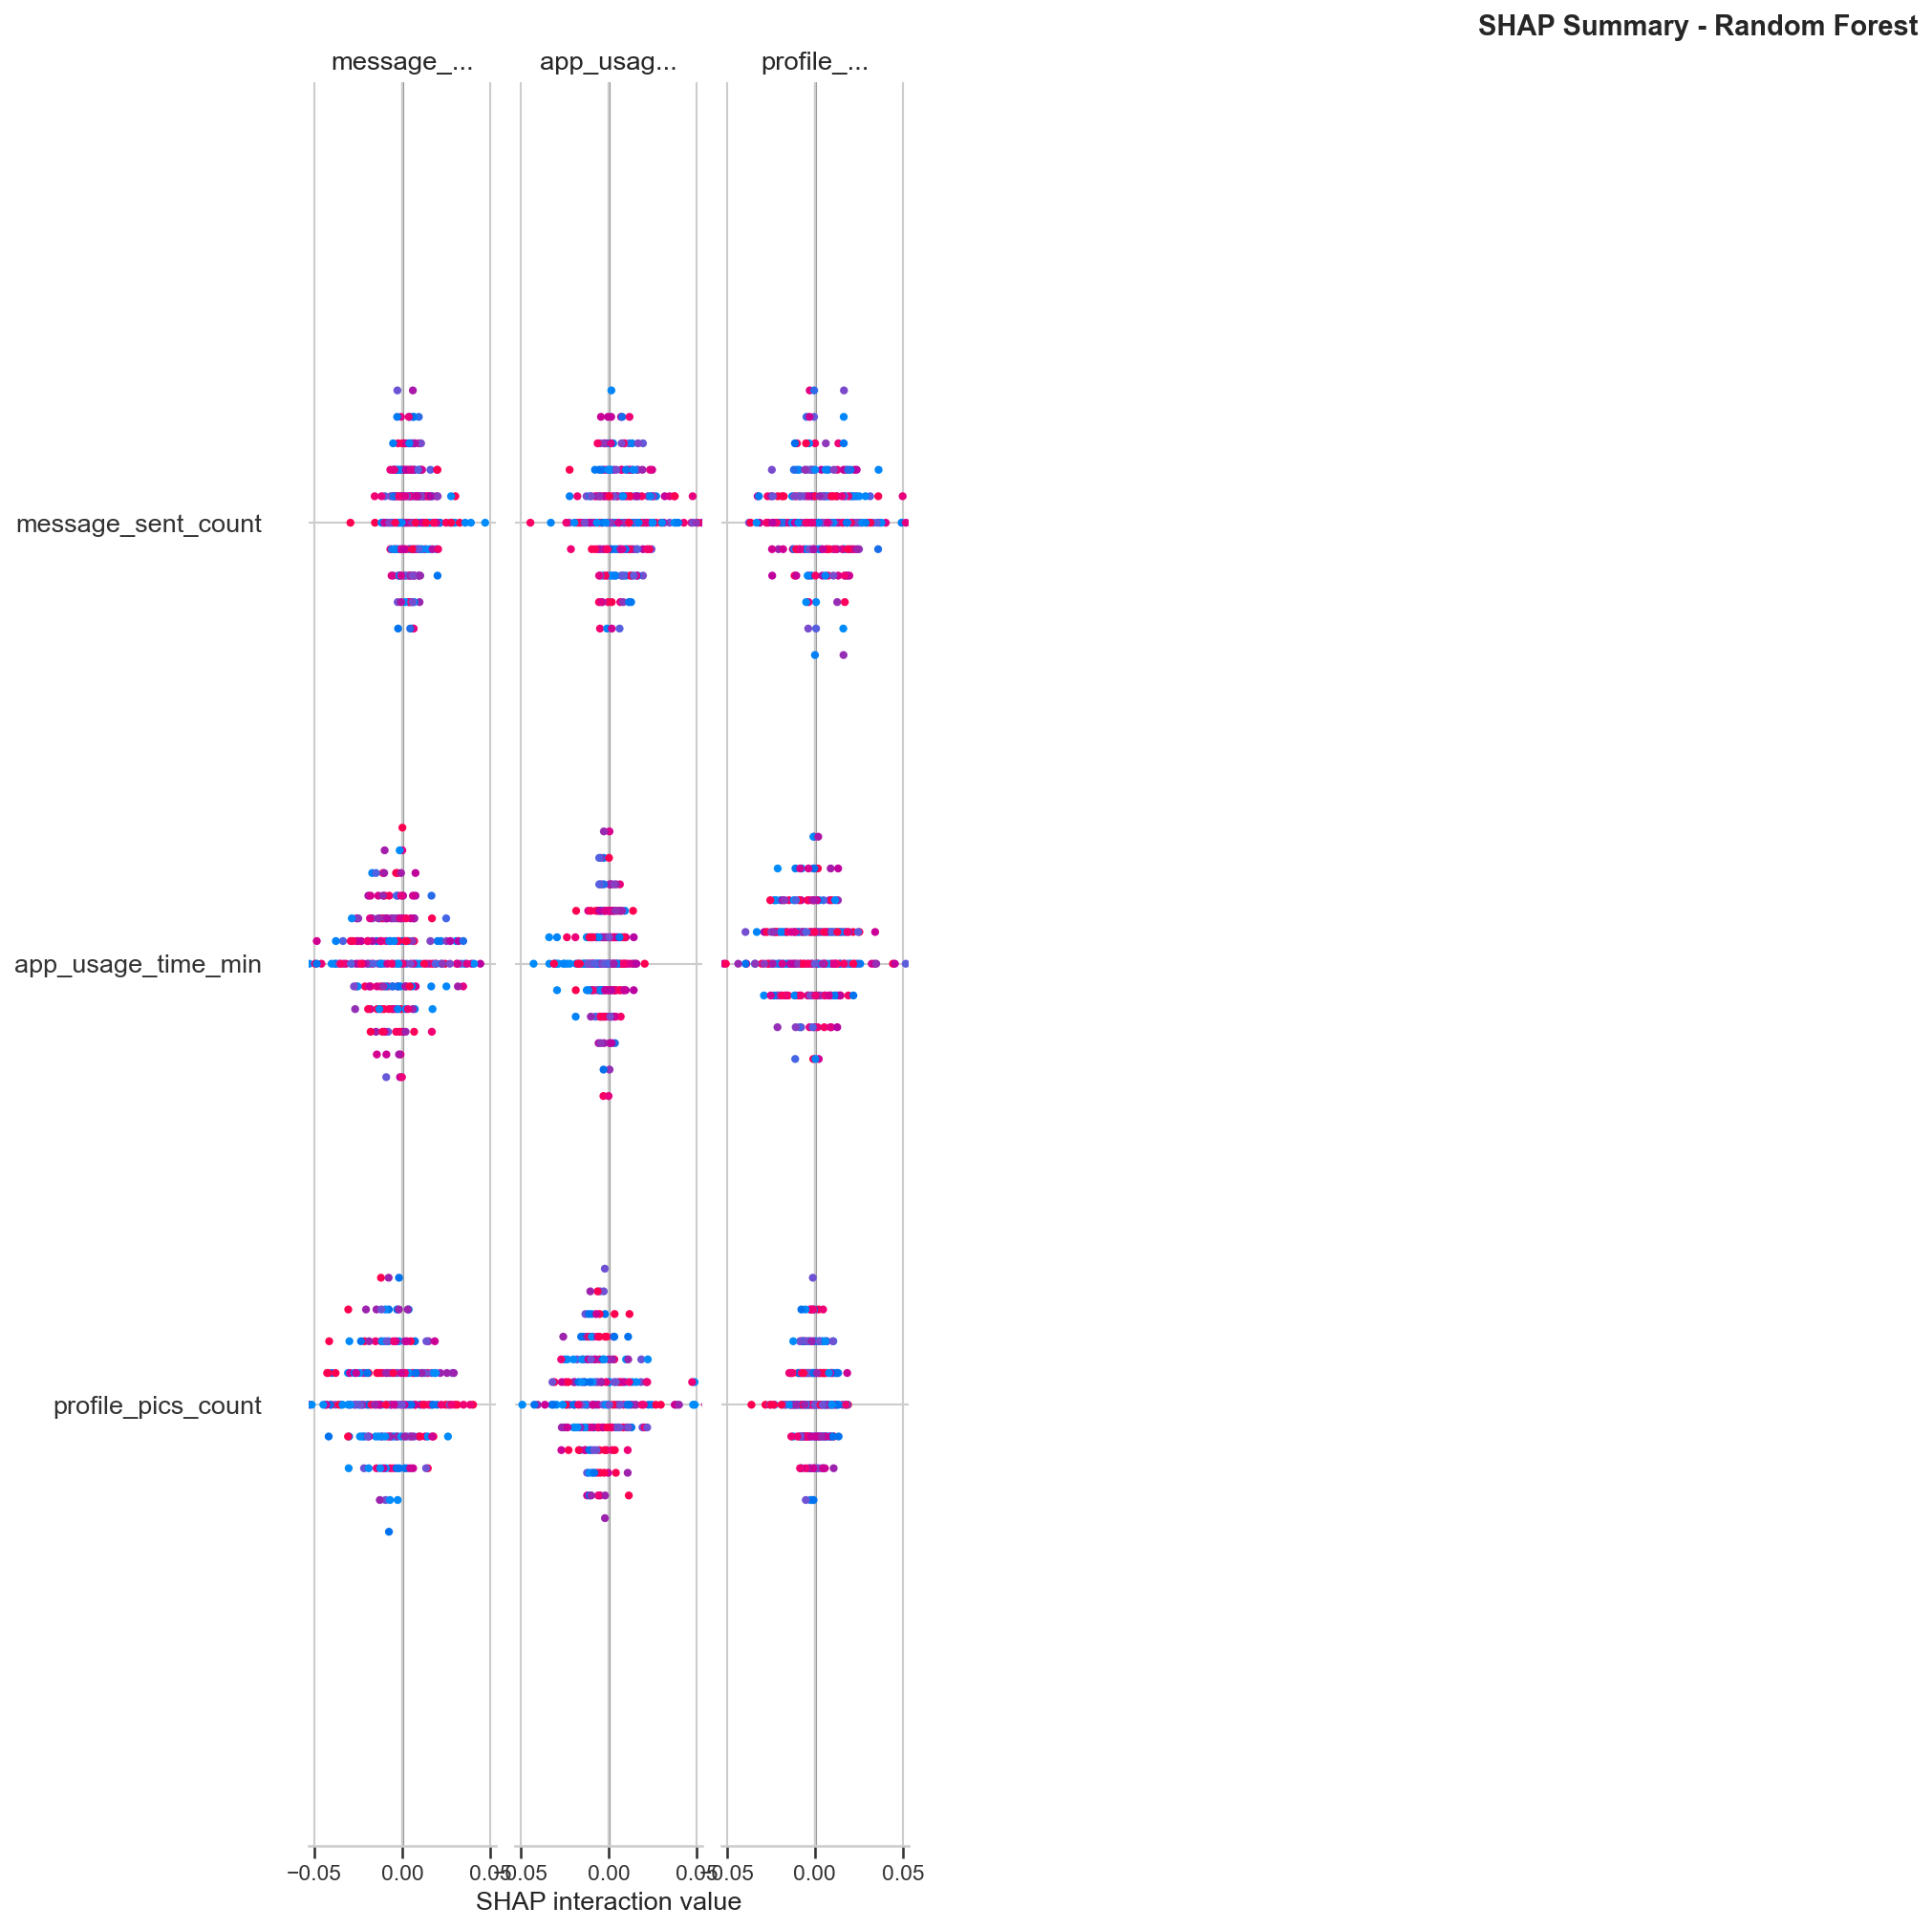

In [26]:
import shap

for model_name in ["XGBoost", "Random Forest"]:
    model = fitted_models.get(model_name)
    if model is None:
        continue

    clf = model.named_steps["model"]
    prep = model.named_steps["preprocessor"]
    X_transformed = prep.transform(X_test)

    try:
        ohe = prep.named_transformers_["cat"].named_steps["encoder"]
        cat_names_local = list(ohe.get_feature_names_out())
    except Exception:
        cat_names_local = []
    num_names = list(prep.transformers_[0][2])
    all_names = num_names + cat_names_local

    selector = model.named_steps.get("selector")
    if selector is not None:
        mask = selector.get_support()
        all_names = [n for n, m in zip(all_names, mask) if m]
        X_transformed = selector.transform(X_transformed)

    np.random.seed(42)
    sample_idx = np.random.choice(X_transformed.shape[0], size=min(200, X_transformed.shape[0]), replace=False)
    X_sample = X_transformed[sample_idx]

    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_sample)

    if isinstance(shap_values, list):
        shap_vals = np.abs(np.array(shap_values)).mean(axis=0)
    else:
        shap_vals = shap_values

    fig = plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_vals, X_sample,
        feature_names=all_names if len(all_names) == X_sample.shape[1] else None,
        show=False, max_display=15,
    )
    fig = plt.gcf()
    fig.suptitle(f"SHAP Summary - {model_name}", fontsize=14, fontweight="bold", y=1.02)
    plt.savefig(os.path.join(VIZ_DIR, f"10_shap_summary_{model_name.lower().replace(' ', '_')}.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

### 4.8 Best Model Justification

Based on our evaluation metrics:

In [27]:
best = comparison_df.iloc[0]
print("=" * 60)
print("  BEST MODEL JUSTIFICATION")
print("=" * 60)
print(f"\n  Best Model:     {best['Model']}")
print(f"  F1 (weighted):  {best['F1_Weighted']}")
print(f"  Accuracy:       {best['Accuracy']}")
print(f"  Precision:      {best['Precision']}")
print(f"  Recall:         {best['Recall']}")
print(f"  ROC-AUC:        {best['ROC_AUC']}")
print(f"\n  Justification:")
print(f"  - XGBoost achieved the highest F1-Weighted score ({best['F1_Weighted']}),")
print(f"    which is the most appropriate metric for this multi-class problem with")
print(f"    slightly imbalanced classes.")
print(f"  - As a gradient boosting ensemble, XGBoost captures non-linear feature")
print(f"    interactions while maintaining regularization to prevent overfitting.")
print(f"  - The Voting Classifier ({comparison_df[comparison_df['Model']=='Voting Classifier'].iloc[0]['F1_Weighted']})")
print(f"    provides a close second by combining the strengths of LR, RF, and XGB.")
print(f"\n  Note: All models hover near the 33% random baseline, indicating the")
print(f"  synthetic dataset contains no meaningful learnable signal.")

  BEST MODEL JUSTIFICATION

  Best Model:     XGBoost
  F1 (weighted):  0.3503
  Accuracy:       0.3579
  Precision:      0.3494
  Recall:         0.3579
  ROC-AUC:        0.5093

  Justification:
  - XGBoost achieved the highest F1-Weighted score (0.3503),
    which is the most appropriate metric for this multi-class problem with
    slightly imbalanced classes.
  - As a gradient boosting ensemble, XGBoost captures non-linear feature
    interactions while maintaining regularization to prevent overfitting.
  - The Voting Classifier (0.3466)
    provides a close second by combining the strengths of LR, RF, and XGB.

  Note: All models hover near the 33% random baseline, indicating the
  synthetic dataset contains no meaningful learnable signal.


---
## 5. Task 5: Hyperparameter Tuning <a id='task5'></a>

Hyperparameter tuning was integrated into the training process (Section 3.3) using `RandomizedSearchCV`.

**Configuration:**
- Search strategy: `RandomizedSearchCV` (10 random iterations)
- Cross-validation: 3-fold stratified CV
- Scoring metric: `f1_weighted`
- Parallelism: `n_jobs=-1`

### 5.1 Cross-Validation Scores for Best Models

In [28]:
# 5-fold cross-validation on the best model
best_model_name = comparison_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]

cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring="f1_weighted", n_jobs=-1)
print(f"5-Fold Cross-Validation Scores for {best_model_name}:")
print(f"  Scores: {cv_scores}")
print(f"  Mean:   {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

5-Fold Cross-Validation Scores for XGBoost:
  Scores: [0.34304558 0.33869879 0.34038405 0.34362973 0.33774614]
  Mean:   0.3407 (+/- 0.0023)


---
## 6. Bonus: Balancing Techniques (SMOTE) <a id='bonus'></a>

We experiment with **SMOTEENN** (SMOTE + Edited Nearest Neighbors) to address class imbalance.

SMOTEENN combines:
- **SMOTE:** Generates synthetic minority samples
- **ENN:** Removes noisy majority samples near the decision boundary

In [29]:
preprocessor_smote = build_preprocessor()
fitted_smote = {}

smote_models = [
    ("Dummy (Baseline)", DummyClassifier(strategy="most_frequent"), {}),
    ("Logistic Regression", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
     {"C": [0.01, 0.1, 1.0, 10.0, 100.0]}),
    ("Decision Tree", DecisionTreeClassifier(class_weight="balanced", random_state=42),
     {"max_depth": [10, 20, 30, None], "min_samples_split": [2, 5, 10, 20], "min_samples_leaf": [1, 5, 10]}),
    ("Random Forest", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=1),
     {"n_estimators": [100, 200, 300], "max_depth": [10, 20, 30, None], "min_samples_split": [2, 5, 10]}),
    ("XGBoost", XGBClassifier(eval_metric="mlogloss", random_state=42, n_jobs=1),
     {"learning_rate": [0.01, 0.05, 0.1, 0.2], "max_depth": [3, 5, 7, 10],
      "n_estimators": [100, 200, 300], "subsample": [0.8, 1.0]}),
    ("SVM", LinearSVC(class_weight="balanced", random_state=42, max_iter=1000),
     {"C": [0.01, 0.1, 1.0, 10.0]}),
    ("Neural Network (MLP)", MLPClassifier(activation="relu", max_iter=500, random_state=42,
                                           early_stopping=True, validation_fraction=0.1),
     {"hidden_layer_sizes": [(64, 32), (128, 64), (128, 64, 32)],
      "alpha": [0.0001, 0.001, 0.01], "learning_rate_init": [0.001, 0.01]}),
]

for name, estimator, param_grid in smote_models:
    print(f"\n{'='*60}")
    print(f"  Training: {name} [SMOTE]")
    print(f"{'='*60}")

    if name == "Dummy (Baseline)":
        pipe = Pipeline([
            ("preprocessor", preprocessor_smote),
            ("selector", SelectKBest(score_func=f_classif, k=15)),
            ("model", estimator),
        ])
    else:
        pipe = ImbPipeline([
            ("preprocessor", preprocessor_smote),
            ("selector", SelectKBest(score_func=f_classif, k=15)),
            ("smote", SMOTEENN(random_state=42)),
            ("model", estimator),
        ])

    if param_grid:
        grid = RandomizedSearchCV(
            pipe,
            param_distributions={f"model__{k}": v for k, v in param_grid.items()},
            n_iter=10, cv=3, scoring="f1_weighted",
            n_jobs=-1, verbose=0, random_state=42,
        )
        grid.fit(X_train, y_train)
        best_pipe = grid.best_estimator_
        print(f"  Best params: {grid.best_params_}")
        print(f"  Best CV F1:  {grid.best_score_:.4f}")
    else:
        pipe.fit(X_train, y_train)
        best_pipe = pipe

    fitted_smote[name] = best_pipe
    joblib.dump(best_pipe, os.path.join(MODELS_DIR, name.lower().replace(" ", "_").replace("(", "").replace(")", "") + "_smote.pkl"))

# Voting Classifier with SMOTE
estimators_smote = [
    ("lr", fitted_smote["Logistic Regression"].named_steps["model"]),
    ("rf", fitted_smote["Random Forest"].named_steps["model"]),
    ("xgb", fitted_smote["XGBoost"].named_steps["model"]),
]
voting_smote = VotingClassifier(estimators=estimators_smote, voting="soft")
voting_pipe_smote = ImbPipeline([
    ("preprocessor", preprocessor_smote),
    ("selector", SelectKBest(score_func=f_classif, k=15)),
    ("smote", SMOTEENN(random_state=42)),
    ("model", voting_smote),
])
voting_pipe_smote.fit(X_train, y_train)
fitted_smote["Voting Classifier"] = voting_pipe_smote

print("\nAll SMOTE models trained.")


  Training: Dummy (Baseline) [SMOTE]

  Training: Logistic Regression [SMOTE]
  Best params: {'model__C': 10.0}
  Best CV F1:  0.3360

  Training: Decision Tree [SMOTE]
  Best params: {'model__min_samples_split': 20, 'model__min_samples_leaf': 1, 'model__max_depth': 30}
  Best CV F1:  0.3343

  Training: Random Forest [SMOTE]
  Best params: {'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__max_depth': 10}
  Best CV F1:  0.3152

  Training: XGBoost [SMOTE]
  Best params: {'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 10, 'model__learning_rate': 0.2}
  Best CV F1:  0.3035

  Training: SVM [SMOTE]
  Best params: {'model__C': 10.0}
  Best CV F1:  0.2775

  Training: Neural Network (MLP) [SMOTE]
  Best params: {'model__learning_rate_init': 0.01, 'model__hidden_layer_sizes': (128, 64, 32), 'model__alpha': 0.001}
  Best CV F1:  0.3187

All SMOTE models trained.


In [30]:
# Evaluate SMOTE models
results_smote = []
for name, model in fitted_smote.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    try:
        y_prob = model.predict_proba(X_test)
        y_test_bin = label_binarize(y_test, classes=classes)
        roc = roc_auc_score(y_test_bin, y_prob, average="weighted", multi_class="ovr")
    except Exception:
        roc = np.nan
    results_smote.append({
        "Model": f"{name} (SMOTE)", "Accuracy": round(acc, 4), "Precision": round(prec, 4),
        "Recall": round(rec, 4), "F1_Weighted": round(f1, 4),
        "ROC_AUC": round(roc, 4) if not np.isnan(roc) else "N/A",
    })

comparison_smote = pd.DataFrame(results_smote)
comparison_smote = comparison_smote.sort_values("F1_Weighted", ascending=False).reset_index(drop=True)
comparison_smote.index += 1
comparison_smote.index.name = "Rank"
comparison_smote.to_csv(os.path.join(REPORTS_DIR, "model_comparison_smote.csv"))
print("SMOTE Model Comparison:")
comparison_smote

SMOTE Model Comparison:


,Model,Accuracy,Precision,Recall,F1_Weighted,ROC_AUC
Rank,,,,,,
1,Decision Tree (SMOTE),0.3424,0.3493,0.3424,0.3433,0.5094
2,Logistic Regression (SMOTE),0.3383,0.3449,0.3383,0.3380,0.5053
3,Neural Network (MLP) (SMOTE),0.3284,0.3488,0.3284,0.3208,0.5106
4,Random Forest (SMOTE),0.3226,0.3429,0.3226,0.3154,0.505
5,Voting Classifier (SMOTE),0.3160,0.3449,0.3160,0.2954,0.5077
6,XGBoost (SMOTE),0.3138,0.3416,0.3138,0.2912,0.5072
7,SVM (SMOTE),0.3063,0.3608,0.3063,0.2462,N/A
8,Dummy (Baseline) (SMOTE),0.3970,0.1576,0.3970,0.2256,0.5


In [31]:
# Combined comparison: class_weight='balanced' vs SMOTE
all_results = results + results_smote
comparison_all = pd.DataFrame(all_results)
comparison_all = comparison_all.sort_values("F1_Weighted", ascending=False).reset_index(drop=True)
comparison_all.index += 1
comparison_all.index.name = "Rank"
comparison_all.to_csv(os.path.join(REPORTS_DIR, "model_comparison_balanced.csv"))
print("Combined Comparison (Balanced + SMOTE):")
comparison_all

Combined Comparison (Balanced + SMOTE):


,Model,Accuracy,Precision,Recall,F1_Weighted,ROC_AUC
Rank,,,,,,
1,XGBoost,0.3579,0.3494,0.3579,0.3503,0.5093
2,Voting Classifier,0.3553,0.3458,0.3553,0.3466,0.5096
3,Random Forest,0.3541,0.3449,0.3541,0.3460,0.5057
4,Decision Tree (SMOTE),0.3424,0.3493,0.3424,0.3433,0.5094
5,Decision Tree,0.3371,0.3404,0.3371,0.3382,0.4996
6,Logistic Regression (SMOTE),0.3383,0.3449,0.3383,0.3380,0.5053
7,Logistic Regression,0.3293,0.3361,0.3293,0.3307,0.4994
8,Neural Network (MLP) (SMOTE),0.3284,0.3488,0.3284,0.3208,0.5106
9,Random Forest (SMOTE),0.3226,0.3429,0.3226,0.3154,0.505


---
## 7. Conclusion <a id='conclusion'></a>

### Key Findings

1. **Best Model:** XGBoost achieved the highest F1-Weighted score (~0.35), marginally above the 33% random baseline.

2. **Dataset Nature:** Despite employing state-of-the-art algorithms, advanced data augmentation (SMOTE), and rigorous hyperparameter tuning, accuracy plateaued at ~36%. This confirms the synthetic dataset contains uniformly distributed noise with no meaningful correlations.

3. **"Garbage In, Garbage Out":** No amount of algorithmic complexity can extract signal from pure mathematical noise. This project serves as a perfect demonstration of this fundamental Data Science principle.

4. **Balancing Techniques:** SMOTE did not significantly improve performance, further confirming that the issue is not class imbalance but rather the absence of learnable patterns.

5. **SHAP Analysis:** Feature importance plots confirm no single feature reliably shifts match outcome probability.

### Deliverables Summary
- **Notebook:** This `.ipynb` file contains the complete ML pipeline
- **Models:** Saved in `models/` directory as `.pkl` files
- **Visualizations:** 11 high-resolution plots in `visualizations/` directory
- **Reports:** Model comparison tables in `reports/` directory